# NOTE:
# This notebook was originally executed from:
# /content/drive/MyDrive/notebooks/
# Paths may need to be adjusted if executed from a different directory.

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from tensorflow import keras
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import r2_score
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Concatenate



Connection to drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Getting the dataframe from the drive

In [ ]:
df3 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/df3.csv')
df3

,Time,Front POA1 (W/m2),Front POA2 (W/m2),Rear 1 (W/m2),Rear 2 (W/m2),Rear 3 (W/m2),G,W,B,S,Temperatura C,Humedad_especifica g/kg,Precipitacion mm/hour,Humedad relativa %,tcc,tclw,sin_h,cos_h,sin_doy,cos_doy
0,2021-07-29 00:00:00,0.0,0.0,0.000300,0.00620,0.000800,1.0,0.0,0.0,0.0,22.33,15.81,3.57,94.48,39.964287,0.153527,0.000000,1.000000,-0.455907,-0.890028
1,2021-07-29 00:15:00,0.0,0.0,0.000300,0.00620,0.000800,1.0,0.0,0.0,0.0,22.33,15.81,3.57,94.48,35.300870,0.130069,0.000000,1.000000,-0.455907,-0.890028
2,2021-07-29 00:30:00,0.0,0.0,0.000300,0.00620,0.000800,1.0,0.0,0.0,0.0,22.33,15.81,3.57,94.48,30.637451,0.106611,0.000000,1.000000,-0.455907,-0.890028
3,2021-07-29 00:45:00,0.0,0.0,0.000300,0.00620,0.000800,1.0,0.0,0.0,0.0,22.33,15.81,3.57,94.48,25.974033,0.083153,0.000000,1.000000,-0.455907,-0.890028
4,2021-07-29 01:00:00,0.0,0.0,0.000300,0.00620,0.000800,1.0,0.0,0.0,0.0,22.21,15.70,2.96,94.50,21.310616,0.059695,0.258819,0.965926,-0.455907,-0.890028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125659,2025-05-11 22:45:00,0.0,0.0,0.000331,0.00617,0.000835,0.0,0.0,1.0,0.0,17.28,10.68,0.00,88.15,98.551765,0.000439,-0.500000,0.866025,0.774884,-0.632103
125660,2025-05-11 23:00:00,0.0,0.0,0.000000,0.00000,0.000000,0.0,0.0,1.0,0.0,16.49,10.36,0.00,89.93,99.412260,0.000063,-0.258819,0.965926,0.774884,-0.632103
125661,2025-05-11 23:15:00,0.0,0.0,0.000000,0.00000,0.000000,0.0,0.0,1.0,0.0,16.49,10.36,0.00,89.93,99.502030,0.000048,-0.258819,0.965926,0.774884,-0.632103
125662,2025-05-11 23:30:00,0.0,0.0,0.000000,0.00000,0.000000,0.0,0.0,1.0,0.0,16.49,10.36,0.00,89.93,99.591800,0.000033,-0.258819,0.965926,0.774884,-0.632103


Features of initial df

In [ ]:
df3.shape

(125664, 20)

In [ ]:
df3.dtypes

,0
Time,object
Front POA1 (W/m2),float64
Front POA2 (W/m2),float64
Rear 1 (W/m2),float64
Rear 2 (W/m2),float64
Rear 3 (W/m2),float64
G,float64
W,float64
B,float64
S,float64


In [ ]:
df3['Time']=pd.to_datetime(df3['Time'],format='%Y-%m-%d %H:%M:%S')


Vector of time gaps for window size=96 (1 day)

In [ ]:
time_gaps_train=[9888, 28416, 67584, 70272, 30144, 85440, 87264,87360, 97728, 105888]
time_gaps_val=[5376]
time_gaps_test=[]

Correlation

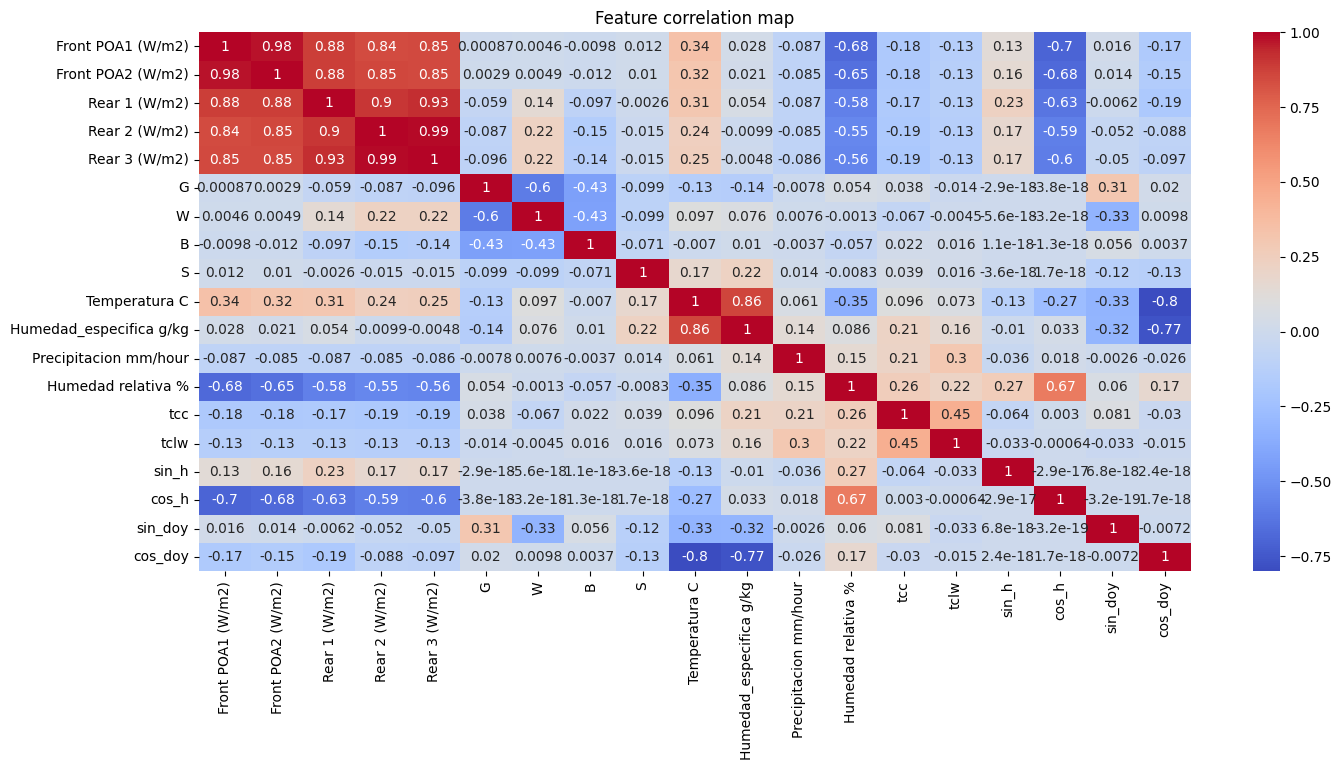

In [ ]:
data_corr=df3.select_dtypes(include=["float64"])
plt.figure(figsize=(16,7))
sns.heatmap(data_corr.corr(),annot=True,cmap="coolwarm")
plt.title("Feature correlation map")
plt.show()

Define seed

In [ ]:
import os
import random
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)
os.environ['PYTHONHASHSEED']=str(42)

Define parameters

In [ ]:
n_exo_var=5  #[2,3,4,5],
#2=[T,relative_humidity],
#3=[T,relative_humidity,tcc],
#4=[T,relative_humidity, tcc ,precipitation]
#5=[T,relative_humidity, tcc, precipitation, specific humidity]
win_size=96 #[4,8,12,16,20,24,....,96,...192,...]
#It is the window that you want to predict, have in mind that t=15min, so win_size=4 means 1 hour
obs_window=384 #[96,192,288,384,480,576,672,...]
#It is the information of the past that you are using to predict
#obs_window=96,192,288, means 1 day, 2 days and 3 days respectively
gap_setting=0 #[96,192,288]
#it is the space (gap) between the last data and the start of horizon

Define Training, validation and testing

In [ ]:
t_n_days=df3.shape[0]/96
training_days=int(t_n_days*0.8)
training_data=training_days*96
validation_data=int((df3.shape[0]-training_data)/2)

training_set=df3.iloc[:training_data,:]
validation_set=df3.iloc[training_data:(training_data+validation_data),:]
testing_set=df3.iloc[(training_data+validation_data):,:]
print(training_set.shape,validation_set.shape,testing_set.shape)

(100512, 20) (12576, 20) (12576, 20)


Define window size for POA1 and POA2

In [ ]:
def df_to_x_y_poa(df_1D,set1,window_size,lookback,n_exo,gap_set,time_gaps):
  df_ref=pd.DataFrame({'Irradiance':np.reshape(df_1D,(df_1D.shape[0]))})

  df_ref['temp']=set1['Temperatura C'].values
  df_ref['hum']=set1['Humedad relativa %'].values

  if n_exo==3:
    df_ref['tcc']=set1['tcc'].values
  if n_exo==4:
    df_ref['tcc']=set1['tcc'].values
    df_ref['prep']=set1['Precipitacion mm/hour'].values
  if n_exo==5:
    df_ref['tcc']=set1['tcc'].values
    df_ref['prep']=set1['Precipitacion mm/hour'].values
    df_ref['esp']=set1['Humedad_especifica g/kg'].values

  df_ref['sin_h']=set1['sin_h'].values
  df_ref['cos_h']=set1['cos_h'].values
  df_ref['sin_doy']=set1['sin_doy'].values
  df_ref['cos_doy']=set1['cos_doy'].values

  X=[]
  y=[]
  i=0
  #future data vs past data
  while i<=len(df_ref)-lookback-window_size-gap_set:
    if n_exo==2:
      X_past=df_ref[['Irradiance','temp','hum','sin_h','cos_h','sin_doy','cos_doy']][i:(i+lookback)].values

    if n_exo==3:
      X_past=df_ref[['Irradiance','temp','hum','tcc','sin_h','cos_h','sin_doy','cos_doy']][i:(i+lookback)].values

    if n_exo==4:
      X_past=df_ref[['Irradiance','temp','hum','tcc','prep','sin_h','cos_h','sin_doy','cos_doy']][i:(i+lookback)].values
    if n_exo==5:
      X_past=df_ref[['Irradiance','temp','hum','tcc','prep','esp','sin_h','cos_h','sin_doy','cos_doy']][i:(i+lookback)].values

    X.append(X_past)
    y.append(df_ref['Irradiance'][(i+lookback+gap_set):(lookback+window_size+i+gap_set)])

    if (lookback+window_size+i+gap_set) in time_gaps:
      if (lookback+window_size+i+gap_set)==87264:
        i=i+window_size*(2+int(lookback/window_size))

      else:
        i=i+window_size*(1+int(lookback/window_size))

    else:
      i=i+window_size


  return np.array(X),np.array(y)

XR_POA1_train,yR_POA1_train=df_to_x_y_poa(training_set['Front POA1 (W/m2)'],training_set,window_size=win_size,
                                          lookback=obs_window,n_exo=n_exo_var,gap_set=gap_setting, time_gaps=time_gaps_train)
XR_POA1_val,yR_POA1_val=df_to_x_y_poa(validation_set['Front POA1 (W/m2)'],validation_set,window_size=win_size,
                                      lookback=obs_window,n_exo=n_exo_var,gap_set=gap_setting,time_gaps=time_gaps_val)
XR_POA1_test,yR_POA1_test=df_to_x_y_poa(testing_set['Front POA1 (W/m2)'],testing_set,window_size=win_size,
                                        lookback=obs_window,n_exo=n_exo_var,gap_set=gap_setting,time_gaps= time_gaps_test)
print(XR_POA1_train.shape)
print(yR_POA1_train.shape)
print(XR_POA1_val.shape)
print(yR_POA1_val.shape)
print(XR_POA1_test.shape)
print(yR_POA1_test.shape)


(1010, 384, 10)
(1010, 96)
(123, 384, 10)
(123, 96)
(127, 384, 10)
(127, 96)


In [ ]:
XR_POA2_train,yR_POA2_train=df_to_x_y_poa(training_set['Front POA2 (W/m2)'],training_set,window_size=win_size,
                                          lookback=obs_window,n_exo=n_exo_var,gap_set=gap_setting, time_gaps=time_gaps_train)
XR_POA2_val,yR_POA2_val=df_to_x_y_poa(validation_set['Front POA2 (W/m2)'],validation_set,window_size=win_size,
                                      lookback=obs_window,n_exo=n_exo_var,gap_set=gap_setting, time_gaps=time_gaps_val)
XR_POA2_test,yR_POA2_test=df_to_x_y_poa(testing_set['Front POA2 (W/m2)'],testing_set,window_size=win_size,
                                        lookback=obs_window,n_exo=n_exo_var,gap_set=gap_setting, time_gaps=time_gaps_test)
print(XR_POA2_train.shape)
print(yR_POA2_train.shape)
print(XR_POA2_val.shape)
print(yR_POA2_val.shape)
print(XR_POA2_test.shape)
print(yR_POA2_test.shape)

(1010, 384, 10)
(1010, 96)
(123, 384, 10)
(123, 96)
(127, 384, 10)
(127, 96)


Define window size for Rear1, Rear2 and Rear3

In [ ]:
def df_to_x_y_rear(df_1D,set1 ,window_size,lookback,n_exo,gap_set, time_gaps):
  df_ref=pd.DataFrame({'Irradiance':np.reshape(df_1D,(df_1D.shape[0]))})

  df_ref['temp']=set1['Temperatura C'].values
  df_ref['hum']=set1['Humedad relativa %'].values

  if n_exo==3:
    df_ref['tcc']=set1['tcc'].values
  if n_exo==4:
    df_ref['tcc']=set1['tcc'].values
    df_ref['prep']=set1['Precipitacion mm/hour'].values
  if n_exo==5:
    df_ref['tcc']=set1['tcc'].values
    df_ref['prep']=set1['Precipitacion mm/hour'].values
    df_ref['esp']=set1['Humedad_especifica g/kg'].values

  df_ref['sin_h']=set1['sin_h'].values
  df_ref['cos_h']=set1['cos_h'].values
  df_ref['sin_doy']=set1['sin_doy'].values
  df_ref['cos_doy']=set1['cos_doy'].values
  df_ref['G']=set1['G'].values
  df_ref['W']=set1['W'].values
  df_ref['B']=set1['B'].values
  df_ref['S']=set1['S'].values

  X=[]
  y=[]
  future_albedo=[]
  i=0
  #future data vs past data
  while i<=len(df_ref)-lookback-window_size-gap_set:
    if n_exo==2:
      X_past=df_ref[['Irradiance','temp','hum','sin_h','cos_h','sin_doy','cos_doy','G','W','B','S']][i:(i+lookback)].values

    if n_exo==3:
      X_past=df_ref[['Irradiance','temp','hum','tcc','sin_h','cos_h','sin_doy','cos_doy','G','W','B','S']][i:(i+lookback)].values

    if n_exo==4:
      X_past=df_ref[['Irradiance','temp','hum','tcc','prep','sin_h','cos_h','sin_doy','cos_doy','G','W','B','S']][i:(i+lookback)].values
    if n_exo==5:
      X_past=df_ref[['Irradiance','temp','hum','tcc','prep','esp','sin_h','cos_h','sin_doy','cos_doy','G','W','B','S']][i:(i+lookback)].values

    X.append(X_past)
    y.append(df_ref['Irradiance'][(i+lookback+gap_set):(lookback+window_size+i+gap_set)])
    future_albedo.append(df_ref[['G','W','B','S']].iloc[(i+lookback+gap_set+48),:])

    if (lookback+window_size+i+gap_set) in time_gaps:
      if (lookback+window_size+i+gap_set)==87264:
        i=i+window_size*(2+int(lookback/window_size))
      else:
        i=i+window_size*(1+int(lookback/window_size))
    else:
      i=i+window_size

  return np.array(X),np.array(y),np.array(future_albedo)

XR_Rear1_train,yR_Rear1_train,surf_Rear1_train=df_to_x_y_rear(training_set['Rear 1 (W/m2)'],training_set,window_size=win_size,
                                                              lookback=obs_window,n_exo=n_exo_var,gap_set=gap_setting, time_gaps=time_gaps_train)
XR_Rear1_val,yR_Rear1_val,surf_Rear1_val=df_to_x_y_rear(validation_set['Rear 1 (W/m2)'],validation_set,window_size=win_size,
                                                              lookback=obs_window,n_exo=n_exo_var,gap_set=gap_setting, time_gaps=time_gaps_val)
XR_Rear1_test,yR_Rear1_test,surf_Rear1_test=df_to_x_y_rear(testing_set['Rear 1 (W/m2)'],testing_set,window_size=win_size,
                                                              lookback=obs_window,n_exo=n_exo_var,gap_set=gap_setting, time_gaps=time_gaps_test)
print(XR_Rear1_train.shape)
print(yR_Rear1_train.shape)
print(surf_Rear1_train.shape)
print(XR_Rear1_val.shape)
print(yR_Rear1_val.shape)
print(surf_Rear1_val.shape)
print(XR_Rear1_test.shape)
print(yR_Rear1_test.shape)
print(surf_Rear1_test.shape)

(1010, 384, 14)
(1010, 96)
(1010, 4)
(123, 384, 14)
(123, 96)
(123, 4)
(127, 384, 14)
(127, 96)
(127, 4)


In [ ]:
XR_Rear2_train,yR_Rear2_train,surf_Rear2_train=df_to_x_y_rear(training_set['Rear 2 (W/m2)'],training_set,window_size=win_size,
                                                              lookback=obs_window,n_exo=n_exo_var,gap_set=gap_setting, time_gaps=time_gaps_train)
XR_Rear2_val,yR_Rear2_val,surf_Rear2_val=df_to_x_y_rear(validation_set['Rear 2 (W/m2)'],validation_set,window_size=win_size,
                                                              lookback=obs_window,n_exo=n_exo_var,gap_set=gap_setting, time_gaps=time_gaps_val)
XR_Rear2_test,yR_Rear2_test,surf_Rear2_test=df_to_x_y_rear(testing_set['Rear 2 (W/m2)'],testing_set,window_size=win_size,
                                                              lookback=obs_window,n_exo=n_exo_var,gap_set=gap_setting, time_gaps=time_gaps_test)
print(XR_Rear2_train.shape)
print(yR_Rear2_train.shape)
print(surf_Rear2_train.shape)
print(XR_Rear2_val.shape)
print(yR_Rear2_val.shape)
print(surf_Rear2_val.shape)
print(XR_Rear2_test.shape)
print(yR_Rear2_test.shape)
print(surf_Rear2_test.shape)

(1010, 384, 14)
(1010, 96)
(1010, 4)
(123, 384, 14)
(123, 96)
(123, 4)
(127, 384, 14)
(127, 96)
(127, 4)


In [ ]:
XR_Rear3_train,yR_Rear3_train,surf_Rear3_train=df_to_x_y_rear(training_set['Rear 3 (W/m2)'],training_set,window_size=win_size,
                                                              lookback=obs_window,n_exo=n_exo_var,gap_set=gap_setting, time_gaps=time_gaps_train)
XR_Rear3_val,yR_Rear3_val,surf_Rear3_val=df_to_x_y_rear(validation_set['Rear 3 (W/m2)'],validation_set,window_size=win_size,
                                                              lookback=obs_window,n_exo=n_exo_var,gap_set=gap_setting, time_gaps=time_gaps_val)
XR_Rear3_test,yR_Rear3_test,surf_Rear3_test=df_to_x_y_rear(testing_set['Rear 3 (W/m2)'],testing_set,window_size=win_size,
                                                              lookback=obs_window,n_exo=n_exo_var,gap_set=gap_setting, time_gaps=time_gaps_test)
print(XR_Rear3_train.shape)
print(yR_Rear3_train.shape)
print(surf_Rear3_train.shape)
print(XR_Rear3_val.shape)
print(yR_Rear3_val.shape)
print(surf_Rear3_val.shape)
print(XR_Rear3_test.shape)
print(yR_Rear3_test.shape)
print(surf_Rear3_test.shape)

(1010, 384, 14)
(1010, 96)
(1010, 4)
(123, 384, 14)
(123, 96)
(123, 4)
(127, 384, 14)
(127, 96)
(127, 4)


Implement RobustScaler

In [ ]:
from sklearn.preprocessing import RobustScaler
scaler_POA1=RobustScaler().fit(XR_POA1_train[:,:,0].reshape(-1,1))
scaler_POA2=RobustScaler().fit(XR_POA2_train[:,:,0].reshape(-1,1))
scaler_Rear1=RobustScaler().fit(XR_Rear1_train[:,:,0].reshape(-1,1))
scaler_Rear2=RobustScaler().fit(XR_Rear2_train[:,:,0].reshape(-1,1))
scaler_Rear3=RobustScaler().fit(XR_Rear3_train[:,:,0].reshape(-1,1))
#If you use the same parameters (window_size,n_exo_var,obs_window) for POA and REAR
#Then you can normalize the other variables with one df
scaler_Temp=RobustScaler().fit(XR_POA1_train[:,:,1].reshape(-1,1))
scaler_Hum=RobustScaler().fit(XR_POA1_train[:,:,2].reshape(-1,1))

if n_exo_var==4:
  scaler_Prep=RobustScaler().fit(XR_POA1_train[:,:,4].reshape(-1,1))

if n_exo_var==5:
  scaler_Prep=RobustScaler().fit(XR_POA1_train[:,:,4].reshape(-1,1))
  scaler_esp=RobustScaler().fit(XR_POA1_train[:,:,5].reshape(-1,1))


In [ ]:

X1_POA1_train=XR_POA1_train
y1_POA1_train=yR_POA1_train
X1_POA2_train=XR_POA2_train
y1_POA2_train=yR_POA2_train
X1_Rear1_train=XR_Rear1_train
y1_Rear1_train=yR_Rear1_train
X1_Rear2_train=XR_Rear2_train
y1_Rear2_train=yR_Rear2_train
X1_Rear3_train=XR_Rear3_train
y1_Rear3_train=yR_Rear3_train

X1_POA1_val=XR_POA1_val
y1_POA1_val=yR_POA1_val
X1_POA2_val=XR_POA2_val
y1_POA2_val=yR_POA2_val
X1_Rear1_val=XR_Rear1_val
y1_Rear1_val=yR_Rear1_val
X1_Rear2_val=XR_Rear2_val
y1_Rear2_val=yR_Rear2_val
X1_Rear3_val=XR_Rear3_val
y1_Rear3_val=yR_Rear3_val

X1_POA1_test=XR_POA1_test
X1_POA2_test=XR_POA2_test
X1_Rear1_test=XR_Rear1_test
X1_Rear2_test=XR_Rear2_test
X1_Rear3_test=XR_Rear3_test

Transform with the scalers created

In [ ]:
X1_POA1_train[:,:,0]=(scaler_POA1.transform(XR_POA1_train[:,:,0].reshape(-1,1))).reshape(XR_POA1_train.shape[0],XR_POA1_train.shape[1])
y1_POA1_train[:,:]=(scaler_POA1.transform(yR_POA1_train[:,:].reshape(-1,1))).reshape(yR_POA1_train.shape[0],yR_POA1_train.shape[1])

X1_POA1_val[:,:,0]=(scaler_POA1.transform(XR_POA1_val[:,:,0].reshape(-1,1))).reshape(XR_POA1_val.shape[0],XR_POA1_val.shape[1])
y1_POA1_val[:,:]=(scaler_POA1.transform(yR_POA1_val[:,:].reshape(-1,1))).reshape(yR_POA1_val.shape[0],yR_POA1_val.shape[1])

X1_POA1_test[:,:,0]=(scaler_POA1.transform(XR_POA1_test[:,:,0].reshape(-1,1))).reshape(XR_POA1_test.shape[0],XR_POA1_test.shape[1])

X1_POA1_train[:,:,1]=(scaler_Temp.transform(XR_POA1_train[:,:,1].reshape(-1,1))).reshape(XR_POA1_train.shape[0],XR_POA1_train.shape[1])
X1_POA1_val[:,:,1]=(scaler_Temp.transform(XR_POA1_val[:,:,1].reshape(-1,1))).reshape(XR_POA1_val.shape[0],XR_POA1_val.shape[1])

X1_POA1_test[:,:,1]=(scaler_Temp.transform(XR_POA1_test[:,:,1].reshape(-1,1))).reshape(XR_POA1_test.shape[0],XR_POA1_test.shape[1])

X1_POA1_train[:,:,2]=(scaler_Hum.transform(XR_POA1_train[:,:,2].reshape(-1,1))).reshape(XR_POA1_train.shape[0],XR_POA1_train.shape[1])
X1_POA1_val[:,:,2]=(scaler_Hum.transform(XR_POA1_val[:,:,2].reshape(-1,1))).reshape(XR_POA1_val.shape[0],XR_POA1_val.shape[1])

X1_POA1_test[:,:,2]=(scaler_Hum.transform(XR_POA1_test[:,:,2].reshape(-1,1))).reshape(XR_POA1_test.shape[0],XR_POA1_test.shape[1])

if n_exo_var==3:
  X1_POA1_train[:,:,3]=XR_POA1_train[:,:,3]/100
  X1_POA1_val[:,:,3]=XR_POA1_val[:,:,3]/100
  X1_POA1_test[:,:,3]=XR_POA1_test[:,:,3]/100

if n_exo_var==4:
  X1_POA1_train[:,:,3]=XR_POA1_train[:,:,3]/100
  X1_POA1_val[:,:,3]=XR_POA1_val[:,:,3]/100
  X1_POA1_test[:,:,3]=XR_POA1_test[:,:,3]/100
  X1_POA1_train[:,:,4]=(scaler_Prep.transform(XR_POA1_train[:,:,4].reshape(-1,1))).reshape(XR_POA1_train.shape[0],XR_POA1_train.shape[1])
  X1_POA1_val[:,:,4]=(scaler_Prep.transform(XR_POA1_val[:,:,4].reshape(-1,1))).reshape(XR_POA1_val.shape[0],XR_POA1_val.shape[1])
  X1_POA1_test[:,:,4]=(scaler_Prep.transform(XR_POA1_test[:,:,4].reshape(-1,1))).reshape(XR_POA1_test.shape[0],XR_POA1_test.shape[1])
if n_exo_var==5:
  X1_POA1_train[:,:,3]=XR_POA1_train[:,:,3]/100
  X1_POA1_val[:,:,3]=XR_POA1_val[:,:,3]/100
  X1_POA1_test[:,:,3]=XR_POA1_test[:,:,3]/100
  X1_POA1_train[:,:,4]=(scaler_Prep.transform(XR_POA1_train[:,:,4].reshape(-1,1))).reshape(XR_POA1_train.shape[0],XR_POA1_train.shape[1])
  X1_POA1_val[:,:,4]=(scaler_Prep.transform(XR_POA1_val[:,:,4].reshape(-1,1))).reshape(XR_POA1_val.shape[0],XR_POA1_val.shape[1])
  X1_POA1_test[:,:,4]=(scaler_Prep.transform(XR_POA1_test[:,:,4].reshape(-1,1))).reshape(XR_POA1_test.shape[0],XR_POA1_test.shape[1])
  X1_POA1_train[:,:,5]=(scaler_esp.transform(XR_POA1_train[:,:,5].reshape(-1,1))).reshape(XR_POA1_train.shape[0],XR_POA1_train.shape[1])
  X1_POA1_val[:,:,5]=(scaler_esp.transform(XR_POA1_val[:,:,5].reshape(-1,1))).reshape(XR_POA1_val.shape[0],XR_POA1_val.shape[1])
  X1_POA1_test[:,:,5]=(scaler_esp.transform(XR_POA1_test[:,:,5].reshape(-1,1))).reshape(XR_POA1_test.shape[0],XR_POA1_test.shape[1])


In [ ]:
X1_POA2_train[:,:,0]=(scaler_POA2.transform(XR_POA2_train[:,:,0].reshape(-1,1))).reshape(XR_POA2_train.shape[0],XR_POA2_train.shape[1])
y1_POA2_train[:,:]=(scaler_POA2.transform(yR_POA2_train[:,:].reshape(-1,1))).reshape(yR_POA2_train.shape[0],yR_POA2_train.shape[1])

X1_POA2_val[:,:,0]=(scaler_POA2.transform(XR_POA2_val[:,:,0].reshape(-1,1))).reshape(XR_POA2_val.shape[0],XR_POA2_val.shape[1])
y1_POA2_val[:,:]=(scaler_POA2.transform(yR_POA2_val[:,:].reshape(-1,1))).reshape(yR_POA2_val.shape[0],yR_POA2_val.shape[1])

X1_POA2_test[:,:,0]=(scaler_POA2.transform(XR_POA2_test[:,:,0].reshape(-1,1))).reshape(XR_POA2_test.shape[0],XR_POA2_test.shape[1])

X1_POA2_train[:,:,1]=(scaler_Temp.transform(XR_POA2_train[:,:,1].reshape(-1,1))).reshape(XR_POA2_train.shape[0],XR_POA2_train.shape[1])
X1_POA2_val[:,:,1]=(scaler_Temp.transform(XR_POA2_val[:,:,1].reshape(-1,1))).reshape(XR_POA2_val.shape[0],XR_POA2_val.shape[1])

X1_POA2_test[:,:,1]=(scaler_Temp.transform(XR_POA2_test[:,:,1].reshape(-1,1))).reshape(XR_POA2_test.shape[0],XR_POA2_test.shape[1])

X1_POA2_train[:,:,2]=(scaler_Hum.transform(XR_POA2_train[:,:,2].reshape(-1,1))).reshape(XR_POA2_train.shape[0],XR_POA2_train.shape[1])
X1_POA2_val[:,:,2]=(scaler_Hum.transform(XR_POA2_val[:,:,2].reshape(-1,1))).reshape(XR_POA2_val.shape[0],XR_POA2_val.shape[1])

X1_POA2_test[:,:,2]=(scaler_Hum.transform(XR_POA2_test[:,:,2].reshape(-1,1))).reshape(XR_POA2_test.shape[0],XR_POA2_test.shape[1])
if n_exo_var==3:
  X1_POA2_train[:,:,3]=XR_POA2_train[:,:,3]/100
  X1_POA2_val[:,:,3]=XR_POA2_val[:,:,3]/100
  X1_POA2_test[:,:,3]=XR_POA2_test[:,:,3]/100
if n_exo_var==4:
  X1_POA2_train[:,:,3]=XR_POA2_train[:,:,3]/100
  X1_POA2_val[:,:,3]=XR_POA2_val[:,:,3]/100
  X1_POA2_test[:,:,3]=XR_POA2_test[:,:,3]/100
  X1_POA2_train[:,:,4]=(scaler_Prep.transform(XR_POA2_train[:,:,4].reshape(-1,1))).reshape(XR_POA2_train.shape[0],XR_POA2_train.shape[1])
  X1_POA2_val[:,:,4]=(scaler_Prep.transform(XR_POA2_val[:,:,4].reshape(-1,1))).reshape(XR_POA2_val.shape[0],XR_POA2_val.shape[1])
  X1_POA2_test[:,:,4]=(scaler_Prep.transform(XR_POA2_test[:,:,4].reshape(-1,1))).reshape(XR_POA2_test.shape[0],XR_POA2_test.shape[1])
if n_exo_var==5:
  X1_POA2_train[:,:,3]=XR_POA2_train[:,:,3]/100
  X1_POA2_val[:,:,3]=XR_POA2_val[:,:,3]/100
  X1_POA2_test[:,:,3]=XR_POA2_test[:,:,3]/100
  X1_POA2_train[:,:,4]=(scaler_Prep.transform(XR_POA2_train[:,:,4].reshape(-1,1))).reshape(XR_POA2_train.shape[0],XR_POA2_train.shape[1])
  X1_POA2_val[:,:,4]=(scaler_Prep.transform(XR_POA2_val[:,:,4].reshape(-1,1))).reshape(XR_POA2_val.shape[0],XR_POA2_val.shape[1])
  X1_POA2_test[:,:,4]=(scaler_Prep.transform(XR_POA2_test[:,:,4].reshape(-1,1))).reshape(XR_POA2_test.shape[0],XR_POA2_test.shape[1])
  X1_POA2_train[:,:,5]=(scaler_esp.transform(XR_POA2_train[:,:,5].reshape(-1,1))).reshape(XR_POA2_train.shape[0],XR_POA2_train.shape[1])
  X1_POA2_val[:,:,5]=(scaler_esp.transform(XR_POA2_val[:,:,5].reshape(-1,1))).reshape(XR_POA2_val.shape[0],XR_POA2_val.shape[1])
  X1_POA2_test[:,:,5]=(scaler_esp.transform(XR_POA2_test[:,:,5].reshape(-1,1))).reshape(XR_POA2_test.shape[0],XR_POA2_test.shape[1])

In [ ]:
X1_Rear1_train[:,:,0]=(scaler_Rear1.transform(XR_Rear1_train[:,:,0].reshape(-1,1))).reshape(XR_Rear1_train.shape[0],XR_Rear1_train.shape[1])
y1_Rear1_train[:,:]=(scaler_Rear1.transform(yR_Rear1_train[:,:].reshape(-1,1))).reshape(yR_Rear1_train.shape[0],yR_Rear1_train.shape[1])

X1_Rear1_val[:,:,0]=(scaler_Rear1.transform(XR_Rear1_val[:,:,0].reshape(-1,1))).reshape(XR_Rear1_val.shape[0],XR_Rear1_val.shape[1])
y1_Rear1_val[:,:]=(scaler_Rear1.transform(yR_Rear1_val[:,:].reshape(-1,1))).reshape(yR_Rear1_val.shape[0],yR_Rear1_val.shape[1])

X1_Rear1_test[:,:,0]=(scaler_Rear1.transform(XR_Rear1_test[:,:,0].reshape(-1,1))).reshape(XR_Rear1_test.shape[0],XR_Rear1_test.shape[1])

X1_Rear1_train[:,:,1]=(scaler_Temp.transform(XR_Rear1_train[:,:,1].reshape(-1,1))).reshape(XR_Rear1_train.shape[0],XR_Rear1_train.shape[1])
X1_Rear1_val[:,:,1]=(scaler_Temp.transform(XR_Rear1_val[:,:,1].reshape(-1,1))).reshape(XR_Rear1_val.shape[0],XR_Rear1_val.shape[1])

X1_Rear1_test[:,:,1]=(scaler_Temp.transform(XR_Rear1_test[:,:,1].reshape(-1,1))).reshape(XR_Rear1_test.shape[0],XR_Rear1_test.shape[1])

X1_Rear1_train[:,:,2]=(scaler_Hum.transform(XR_Rear1_train[:,:,2].reshape(-1,1))).reshape(XR_Rear1_train.shape[0],XR_Rear1_train.shape[1])
X1_Rear1_val[:,:,2]=(scaler_Hum.transform(XR_Rear1_val[:,:,2].reshape(-1,1))).reshape(XR_Rear1_val.shape[0],XR_Rear1_val.shape[1])

X1_Rear1_test[:,:,2]=(scaler_Hum.transform(XR_Rear1_test[:,:,2].reshape(-1,1))).reshape(XR_Rear1_test.shape[0],XR_Rear1_test.shape[1])

if n_exo_var==3:
  X1_Rear1_train[:,:,3]=(XR_Rear1_train[:,:,3]/100)
  X1_Rear1_val[:,:,3]=(XR_Rear1_val[:,:,3]/100)
  X1_Rear1_test[:,:,3]=(XR_Rear1_test[:,:,3]/100)
if n_exo_var==4:
  X1_Rear1_train[:,:,3]=(XR_Rear1_train[:,:,3]/100)
  X1_Rear1_val[:,:,3]=(XR_Rear1_val[:,:,3]/100)
  X1_Rear1_test[:,:,3]=(XR_Rear1_test[:,:,3]/100)
  X1_Rear1_train[:,:,4]=(scaler_Prep.transform(XR_Rear1_train[:,:,4].reshape(-1,1))).reshape(XR_Rear1_train.shape[0],XR_Rear1_train.shape[1])
  X1_Rear1_val[:,:,4]=(scaler_Prep.transform(XR_Rear1_val[:,:,4].reshape(-1,1))).reshape(XR_Rear1_val.shape[0],XR_Rear1_val.shape[1])
  X1_Rear1_test[:,:,4]=(scaler_Prep.transform(XR_Rear1_test[:,:,4].reshape(-1,1))).reshape(XR_Rear1_test.shape[0],XR_Rear1_test.shape[1])

if n_exo_var==5:
  X1_Rear1_train[:,:,3]=(XR_Rear1_train[:,:,3]/100)
  X1_Rear1_val[:,:,3]=(XR_Rear1_val[:,:,3]/100)
  X1_Rear1_test[:,:,3]=(XR_Rear1_test[:,:,3]/100)
  X1_Rear1_train[:,:,4]=(scaler_Prep.transform(XR_Rear1_train[:,:,4].reshape(-1,1))).reshape(XR_Rear1_train.shape[0],XR_Rear1_train.shape[1])
  X1_Rear1_val[:,:,4]=(scaler_Prep.transform(XR_Rear1_val[:,:,4].reshape(-1,1))).reshape(XR_Rear1_val.shape[0],XR_Rear1_val.shape[1])
  X1_Rear1_test[:,:,4]=(scaler_Prep.transform(XR_Rear1_test[:,:,4].reshape(-1,1))).reshape(XR_Rear1_test.shape[0],XR_Rear1_test.shape[1])
  X1_Rear1_train[:,:,5]=(scaler_esp.transform(XR_Rear1_train[:,:,5].reshape(-1,1))).reshape(XR_Rear1_train.shape[0],XR_Rear1_train.shape[1])
  X1_Rear1_val[:,:,5]=(scaler_esp.transform(XR_Rear1_val[:,:,5].reshape(-1,1))).reshape(XR_Rear1_val.shape[0],XR_Rear1_val.shape[1])
  X1_Rear1_test[:,:,5]=(scaler_esp.transform(XR_Rear1_test[:,:,5].reshape(-1,1))).reshape(XR_Rear1_test.shape[0],XR_Rear1_test.shape[1])

#

In [ ]:
X1_Rear2_train[:,:,0]=(scaler_Rear2.transform(XR_Rear2_train[:,:,0].reshape(-1,1))).reshape(XR_Rear2_train.shape[0],XR_Rear2_train.shape[1])
y1_Rear2_train[:,:]=(scaler_Rear2.transform(yR_Rear2_train[:,:].reshape(-1,1))).reshape(yR_Rear2_train.shape[0],yR_Rear2_train.shape[1])

X1_Rear2_val[:,:,0]=(scaler_Rear2.transform(XR_Rear2_val[:,:,0].reshape(-1,1))).reshape(XR_Rear2_val.shape[0],XR_Rear2_val.shape[1])
y1_Rear2_val[:,:]=(scaler_Rear2.transform(yR_Rear2_val[:,:].reshape(-1,1))).reshape(yR_Rear2_val.shape[0],yR_Rear2_val.shape[1])

X1_Rear2_test[:,:,0]=(scaler_Rear2.transform(XR_Rear2_test[:,:,0].reshape(-1,1))).reshape(XR_Rear2_test.shape[0],XR_Rear2_test.shape[1])

X1_Rear2_train[:,:,1]=(scaler_Temp.transform(XR_Rear2_train[:,:,1].reshape(-1,1))).reshape(XR_Rear2_train.shape[0],XR_Rear2_train.shape[1])
X1_Rear2_val[:,:,1]=(scaler_Temp.transform(XR_Rear2_val[:,:,1].reshape(-1,1))).reshape(XR_Rear2_val.shape[0],XR_Rear2_val.shape[1])

X1_Rear2_test[:,:,1]=(scaler_Temp.transform(XR_Rear2_test[:,:,1].reshape(-1,1))).reshape(XR_Rear2_test.shape[0],XR_Rear2_test.shape[1])

X1_Rear2_train[:,:,2]=(scaler_Hum.transform(XR_Rear2_train[:,:,2].reshape(-1,1))).reshape(XR_Rear2_train.shape[0],XR_Rear2_train.shape[1])
X1_Rear2_val[:,:,2]=(scaler_Hum.transform(XR_Rear2_val[:,:,2].reshape(-1,1))).reshape(XR_Rear2_val.shape[0],XR_Rear2_val.shape[1])

X1_Rear2_test[:,:,2]=(scaler_Hum.transform(XR_Rear2_test[:,:,2].reshape(-1,1))).reshape(XR_Rear2_test.shape[0],XR_Rear2_test.shape[1])

if n_exo_var==3:
  X1_Rear2_train[:,:,3]=(XR_Rear2_train[:,:,3]/100)
  X1_Rear2_val[:,:,3]=(XR_Rear2_val[:,:,3]/100)
  X1_Rear2_test[:,:,3]=(XR_Rear2_test[:,:,3]/100)
if n_exo_var==4:
  X1_Rear2_train[:,:,3]=(XR_Rear2_train[:,:,3]/100)
  X1_Rear2_val[:,:,3]=(XR_Rear2_val[:,:,3]/100)
  X1_Rear2_test[:,:,3]=(XR_Rear2_test[:,:,3]/100)
  X1_Rear2_train[:,:,4]=(scaler_Prep.transform(XR_Rear2_train[:,:,4].reshape(-1,1))).reshape(XR_Rear2_train.shape[0],XR_Rear2_train.shape[1])
  X1_Rear2_val[:,:,4]=(scaler_Prep.transform(XR_Rear2_val[:,:,4].reshape(-1,1))).reshape(XR_Rear2_val.shape[0],XR_Rear2_val.shape[1])
  X1_Rear2_test[:,:,4]=(scaler_Prep.transform(XR_Rear2_test[:,:,4].reshape(-1,1))).reshape(XR_Rear2_test.shape[0],XR_Rear2_test.shape[1])

if n_exo_var==5:
  X1_Rear2_train[:,:,3]=(XR_Rear2_train[:,:,3]/100)
  X1_Rear2_val[:,:,3]=(XR_Rear2_val[:,:,3]/100)
  X1_Rear2_test[:,:,3]=(XR_Rear2_test[:,:,3]/100)
  X1_Rear2_train[:,:,4]=(scaler_Prep.transform(XR_Rear2_train[:,:,4].reshape(-1,1))).reshape(XR_Rear2_train.shape[0],XR_Rear2_train.shape[1])
  X1_Rear2_val[:,:,4]=(scaler_Prep.transform(XR_Rear2_val[:,:,4].reshape(-1,1))).reshape(XR_Rear2_val.shape[0],XR_Rear2_val.shape[1])
  X1_Rear2_test[:,:,4]=(scaler_Prep.transform(XR_Rear2_test[:,:,4].reshape(-1,1))).reshape(XR_Rear2_test.shape[0],XR_Rear2_test.shape[1])
  X1_Rear2_train[:,:,5]=(scaler_esp.transform(XR_Rear2_train[:,:,5].reshape(-1,1))).reshape(XR_Rear2_train.shape[0],XR_Rear2_train.shape[1])
  X1_Rear2_val[:,:,5]=(scaler_esp.transform(XR_Rear2_val[:,:,5].reshape(-1,1))).reshape(XR_Rear2_val.shape[0],XR_Rear2_val.shape[1])
  X1_Rear2_test[:,:,5]=(scaler_esp.transform(XR_Rear2_test[:,:,5].reshape(-1,1))).reshape(XR_Rear2_test.shape[0],XR_Rear2_test.shape[1])
#

In [ ]:
X1_Rear3_train[:,:,0]=(scaler_Rear3.transform(XR_Rear3_train[:,:,0].reshape(-1,1))).reshape(XR_Rear3_train.shape[0],XR_Rear3_train.shape[1])
y1_Rear3_train[:,:]=(scaler_Rear3.transform(yR_Rear3_train[:,:].reshape(-1,1))).reshape(yR_Rear3_train.shape[0],yR_Rear3_train.shape[1])

X1_Rear3_val[:,:,0]=(scaler_Rear3.transform(XR_Rear3_val[:,:,0].reshape(-1,1))).reshape(XR_Rear3_val.shape[0],XR_Rear3_val.shape[1])
y1_Rear3_val[:,:]=(scaler_Rear3.transform(yR_Rear3_val[:,:].reshape(-1,1))).reshape(yR_Rear3_val.shape[0],yR_Rear3_val.shape[1])

X1_Rear3_test[:,:,0]=(scaler_Rear3.transform(XR_Rear3_test[:,:,0].reshape(-1,1))).reshape(XR_Rear3_test.shape[0],XR_Rear3_test.shape[1])

X1_Rear3_train[:,:,1]=(scaler_Temp.transform(XR_Rear3_train[:,:,1].reshape(-1,1))).reshape(XR_Rear3_train.shape[0],XR_Rear3_train.shape[1])
X1_Rear3_val[:,:,1]=(scaler_Temp.transform(XR_Rear3_val[:,:,1].reshape(-1,1))).reshape(XR_Rear3_val.shape[0],XR_Rear3_val.shape[1])

X1_Rear3_test[:,:,1]=(scaler_Temp.transform(XR_Rear3_test[:,:,1].reshape(-1,1))).reshape(XR_Rear3_test.shape[0],XR_Rear3_test.shape[1])

X1_Rear3_train[:,:,2]=(scaler_Hum.transform(XR_Rear3_train[:,:,2].reshape(-1,1))).reshape(XR_Rear3_train.shape[0],XR_Rear3_train.shape[1])
X1_Rear3_val[:,:,2]=(scaler_Hum.transform(XR_Rear3_val[:,:,2].reshape(-1,1))).reshape(XR_Rear3_val.shape[0],XR_Rear3_val.shape[1])

X1_Rear3_test[:,:,2]=(scaler_Hum.transform(XR_Rear3_test[:,:,2].reshape(-1,1))).reshape(XR_Rear3_test.shape[0],XR_Rear3_test.shape[1])

if n_exo_var==3:
  X1_Rear3_train[:,:,3]=(XR_Rear3_train[:,:,3]/100)
  X1_Rear3_val[:,:,3]=(XR_Rear3_val[:,:,3]/100)
  X1_Rear3_test[:,:,3]=(XR_Rear3_test[:,:,3]/100)
if n_exo_var==4:
  X1_Rear3_train[:,:,3]=(XR_Rear3_train[:,:,3]/100)
  X1_Rear3_val[:,:,3]=(XR_Rear3_val[:,:,3]/100)
  X1_Rear3_test[:,:,3]=(XR_Rear3_test[:,:,3]/100)
  X1_Rear3_train[:,:,4]=(scaler_Prep.transform(XR_Rear3_train[:,:,4].reshape(-1,1))).reshape(XR_Rear3_train.shape[0],XR_Rear3_train.shape[1])
  X1_Rear3_val[:,:,4]=(scaler_Prep.transform(XR_Rear3_val[:,:,4].reshape(-1,1))).reshape(XR_Rear3_val.shape[0],XR_Rear3_val.shape[1])
  X1_Rear3_test[:,:,4]=(scaler_Prep.transform(XR_Rear3_test[:,:,4].reshape(-1,1))).reshape(XR_Rear3_test.shape[0],XR_Rear3_test.shape[1])
if n_exo_var==5:
  X1_Rear3_train[:,:,3]=(XR_Rear3_train[:,:,3]/100)
  X1_Rear3_val[:,:,3]=(XR_Rear3_val[:,:,3]/100)
  X1_Rear3_test[:,:,3]=(XR_Rear3_test[:,:,3]/100)
  X1_Rear3_train[:,:,4]=(scaler_Prep.transform(XR_Rear3_train[:,:,4].reshape(-1,1))).reshape(XR_Rear3_train.shape[0],XR_Rear3_train.shape[1])
  X1_Rear3_val[:,:,4]=(scaler_Prep.transform(XR_Rear3_val[:,:,4].reshape(-1,1))).reshape(XR_Rear3_val.shape[0],XR_Rear3_val.shape[1])
  X1_Rear3_test[:,:,4]=(scaler_Prep.transform(XR_Rear3_test[:,:,4].reshape(-1,1))).reshape(XR_Rear3_test.shape[0],XR_Rear3_test.shape[1])
  X1_Rear3_train[:,:,5]=(scaler_esp.transform(XR_Rear3_train[:,:,5].reshape(-1,1))).reshape(XR_Rear3_train.shape[0],XR_Rear3_train.shape[1])
  X1_Rear3_val[:,:,5]=(scaler_esp.transform(XR_Rear3_val[:,:,5].reshape(-1,1))).reshape(XR_Rear3_val.shape[0],XR_Rear3_val.shape[1])
  X1_Rear3_test[:,:,5]=(scaler_esp.transform(XR_Rear3_test[:,:,5].reshape(-1,1))).reshape(XR_Rear3_test.shape[0],XR_Rear3_test.shape[1])

#

Import keras-tuner

In [ ]:
pip install keras-tuner --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 11.0 MB/s eta 0:00:00


In [ ]:
import keras_tuner as kt
from keras_tuner import BayesianOptimization


Define Callbacks

In [ ]:

early_stop1=EarlyStopping(monitor='val_loss',patience=8,restore_best_weights=True)
check_point_poa1=ModelCheckpoint(filepath="model_checkpoint/best_model_poa1.keras",monitor='mae',save_best_only=True)

Define function to optimize hyperparameters

In [ ]:
def create_model_tun_poa(hp):
  inputs_layer=keras.layers.Input(shape=(obs_window,5+n_exo_var))

  x=inputs_layer
  kernel_size1=hp.Choice('kernel_size',[3,5])
  filters1=hp.Choice('filters',[32,64])

  x=keras.layers.Conv1D(filters=filters1,kernel_size=kernel_size1,activation='relu',padding='same')(x)
  x=keras.layers.Conv1D(filters=filters1,kernel_size=kernel_size1,activation='relu',padding='same')(x)

  x=keras.layers.Dropout(hp.Choice('dropout1',[0.1, 0.2]))(x)

  x=keras.layers.GRU(units=hp.Choice('units',[32,64,96]),return_sequences=False)(x)
  x=keras.layers.Dropout(hp.Choice('dropout2',[0.1, 0.2]))(x)
  x=keras.layers.Dense(units=hp.Choice('units_dense',[64,96]),activation='relu')(x)

  output=keras.layers.Dense(win_size)(x)
  model=keras.models.Model(inputs=inputs_layer,outputs=output)

  model.compile(optimizer=Adam(hp.Choice('lr',[1e-3,5e-4])),loss='mae',metrics=['mae','mse','mape'])
  return model

Define object tuner

In [ ]:
tuner_POA1=BayesianOptimization(create_model_tun_poa,objective='val_loss',max_trials=80,num_initial_points=16,alpha=1e-4,beta=2.6,project_name='cnngru2_tunv4_d1')

In [ ]:
tuner_POA1.search(X1_POA1_train,y1_POA1_train,epochs=40,validation_data=(X1_POA1_val,y1_POA1_val),callbacks=[early_stop1])
tuner_POA1.results_summary()

Trial 80 Complete [00h 00m 26s]
val_loss: 0.2144986391067505

Best val_loss So Far: 0.2036852091550827
Total elapsed time: 00h 48m 33s
Results summary
Results in ./cnngru2_tunv4_d1
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 43 summary
Hyperparameters:
kernel_size: 5
filters: 64
dropout1: 0.2
units: 96
dropout2: 0.1
units_dense: 96
lr: 0.0005
Score: 0.2036852091550827

Trial 39 summary
Hyperparameters:
kernel_size: 5
filters: 64
dropout1: 0.2
units: 64
dropout2: 0.1
units_dense: 96
lr: 0.0005
Score: 0.20389603078365326

Trial 76 summary
Hyperparameters:
kernel_size: 5
filters: 64
dropout1: 0.2
units: 96
dropout2: 0.1
units_dense: 96
lr: 0.0005
Score: 0.2046908438205719

Trial 15 summary
Hyperparameters:
kernel_size: 5
filters: 64
dropout1: 0.2
units: 96
dropout2: 0.1
units_dense: 96
lr: 0.0005
Score: 0.20475780963897705

Trial 73 summary
Hyperparameters:
kernel_size: 5
filters: 64
dropout1: 0.2
units: 96
dropout2: 0.1
units_dense: 96
lr: 0.0005
Score: 0.20

Define the model as the best model performed by keras tuner

In [ ]:
model1_POA1_CNNGRU2=tuner_POA1.get_best_models()[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 24 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Save and load model

In [ ]:
model1_POA1_CNNGRU2.save('/content/drive/MyDrive/Colab Notebooks/models_CNNGRU_RS/model_CNNGRU2_POA1_n5.keras')

In [ ]:
model1_POA1_CNNGRU2=keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/models_CNNGRU_RS/model_CNNGRU2_POA1_n5.keras')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Prediction and evaluation

In [ ]:

pred_POA1_p1=model1_POA1_CNNGRU2.predict(X1_POA1_test)
predict_POA1_p1=(scaler_POA1.inverse_transform(pred_POA1_p1.reshape(-1,1))).reshape(pred_POA1_p1.shape[0],pred_POA1_p1.shape[1])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


MAE

In [ ]:
def list_mae(y_true, y_pred):
  mae_list=[]
  for day in range(y_true.shape[0]):
    mae_list.append(mean_absolute_error(y_true[day,:],y_pred[day,:]))
  return mae_list


In [ ]:
real_loss_POA1=list_mae(yR_POA1_test,predict_POA1_p1)
print(np.mean(real_loss_POA1))

74.85386121920124


In [ ]:
print(real_loss_POA1)

[18.60941570373427, 52.34764460895072, 72.89675755654144, 70.62629245845775, 27.359474449245948, 34.56492503258883, 54.83280052241151, 27.579086192682023, 54.672198119332485, 43.50289618718974, 60.21993520153603, 98.62889764431237, 87.75472878937008, 125.69223983699787, 20.653792930139673, 88.82569976742188, 74.30375102027722, 62.90046173739538, 39.514888956242295, 36.25777510426131, 19.251722998273568, 72.79895301250804, 63.446048525611225, 63.17808246298264, 50.28000570220504, 19.151387408197923, 77.01208160017133, 118.01372698112725, 120.63530605838285, 46.36778444444491, 113.70797296017844, 124.59895700231084, 116.36518837405407, 106.714898614642, 163.38004127025002, 60.1243220755998, 61.162981819314204, 160.66735279284157, 53.52497623363394, 43.5121428799302, 61.52921053964576, 122.76565444984988, 108.09727217322747, 55.044530393008664, 102.67378488314252, 134.34531658311894, 115.23183286897466, 54.988484727257024, 18.12263543988691, 54.66520316103074, 27.955471150885618, 50.79512

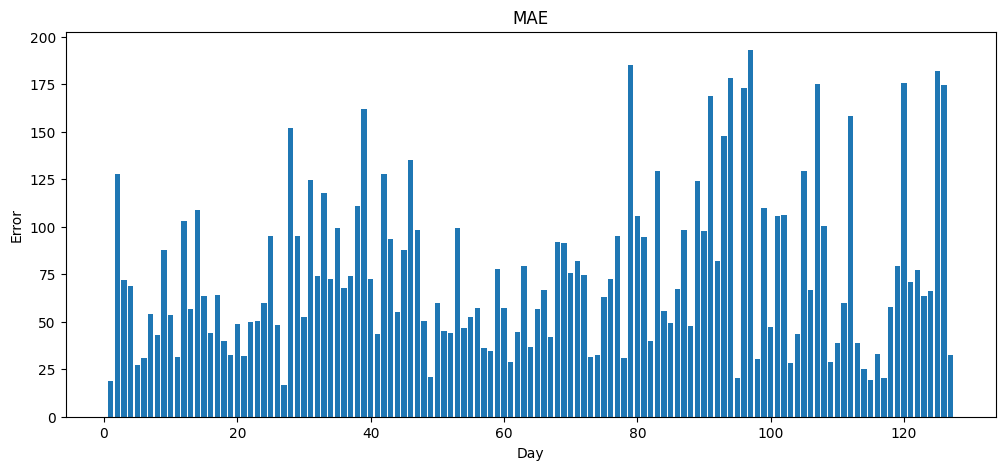

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_loss_POA1)+1), real_loss_POA1)
plt.title("MAE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

R2

In [ ]:
def list_r2(y_true, y_pred):
  r2_list=[]
  for day in range(y_true.shape[0]):
    r2_list.append(r2_score(y_true[day,:],y_pred[day,:]))
  return r2_list

In [ ]:
real_r2_POA1=list_r2(yR_POA1_test,predict_POA1_p1)
print(np.mean(real_r2_POA1))

-11.20593957569


In [ ]:
print(real_r2_POA1)

[0.97534228273069, -775.182596716568, 0.5698645156937847, 0.5851188290367899, 0.9610249214699178, 0.899877697018177, 0.18212017290235083, 0.9499634219174662, -0.5340455038408725, 0.9158512573264418, 0.825570641204322, -5.819514953462603, 0.5998288697721754, -32.01363398288912, -1.2771673297922272, 0.6648182783229056, 0.544541627215847, 0.8395150023926456, 0.9034133514297171, 0.9236738972146473, 0.9789110590960459, -2.2772245393140502, 0.8575484632506739, 0.6201737093350288, 0.8740008805375948, 0.9797815567672145, -38.86488439498889, 0.5145360807754662, -2.6573544095584625, 0.7611858047097906, 0.35570192873498385, -4.166622151838355, -29.23715736270482, 0.30425610530971925, -16.85450128278591, 0.0017373057145755322, 0.8661386463855364, -13.47693604506759, -299.90395342938524, 0.45506352465951094, 0.8836561244329603, -7.166861295116934, -11.723003223234352, 0.8644597657500663, 0.26216784354825606, -4.368035754888119, -1.0366888501622027, 0.8984248889259673, 0.9871316890628186, 0.91784565

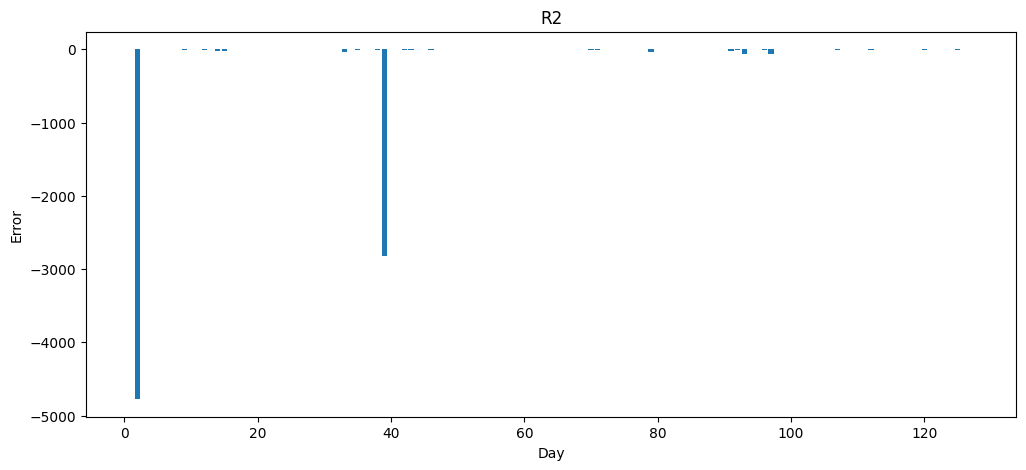

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_r2_POA1)+1), real_r2_POA1)
plt.title("R2")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

In [ ]:
def mape_mod(y_true, y_pred):
  mape_list=[]

  for day in range(y_true.shape[0]):
    y_pred2=[]
    y_true2=[]
    for i in range(0,96):
      if y_true[day,i]>=5 and y_pred[day,i]>=2:
        y_true2.append(y_true[day,i])
        y_pred2.append(y_pred[day,i])
    mape_list.append(np.mean(np.abs((np.array(y_true2) - np.array(y_pred2)) / np.array(y_true2))))
  return mape_list

In [ ]:
real_mape_poa1=mape_mod(yR_POA1_test,predict_POA1_p1)
print(np.mean(real_mape_poa1))

1.5914646329685067


In [ ]:
print(real_mape_poa1)

[np.float64(0.3269156743641203), np.float64(20.328035177183782), np.float64(3.6409490002047056), np.float64(1.017947165781972), np.float64(0.30722738793499493), np.float64(0.4802843580859541), np.float64(4.417398119137283), np.float64(0.470845597353329), np.float64(1.1719520137102026), np.float64(0.3640091524346713), np.float64(0.3623655097487871), np.float64(2.5398534070575374), np.float64(0.8011251349944355), np.float64(4.664325353224711), np.float64(2.1494473026368532), np.float64(0.608723962874342), np.float64(1.2485149674152876), np.float64(0.6223282290428049), np.float64(0.32818007289461437), np.float64(0.6141453962893286), np.float64(0.3334855683079713), np.float64(1.5299587170598077), np.float64(0.3654540950765305), np.float64(0.7436266559811923), np.float64(0.4288326764856342), np.float64(0.2962073543616895), np.float64(8.001957721425017), np.float64(0.6381289874692949), np.float64(2.6737589643643993), np.float64(0.39880387526891886), np.float64(0.5781200934291929), np.float64

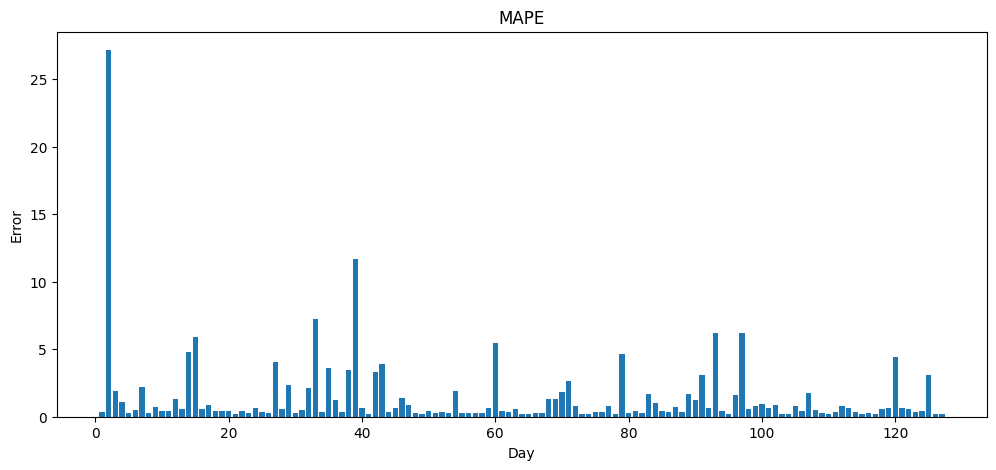

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_mape_poa1)+1), real_mape_poa1)
plt.title("MAPE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

Check the graphs to understand atypical errors

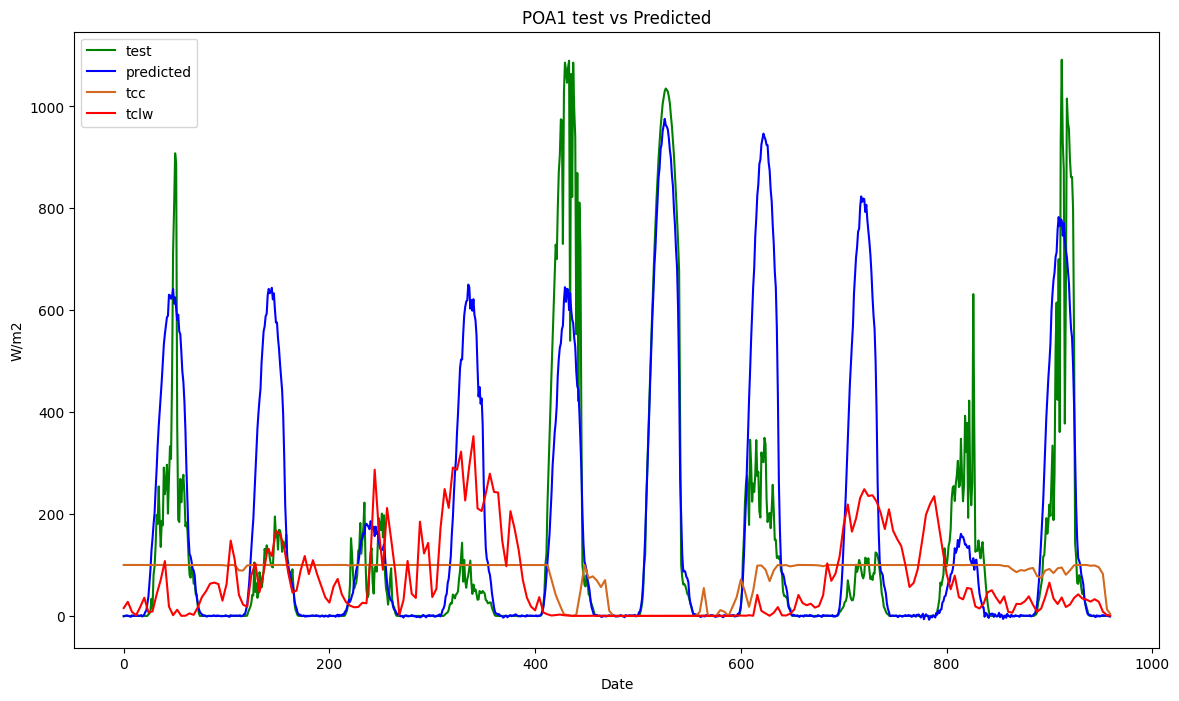

In [ ]:
plt.figure(figsize=(14,8))
st_day=90
end_day=100
dat_clouds=yR_POA1_test.shape[0]*yR_POA1_test.shape[1]
i_clouds=len(df3)-dat_clouds+(st_day-1)*96
f_clouds=i_clouds+(end_day-st_day)*96
plt.plot(yR_POA1_test.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='test',color='green')
plt.plot(predict_POA1_p1.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='predicted',color='blue')
plt.plot(df3['tcc'].values[i_clouds:f_clouds],label='tcc',color='chocolate')
plt.plot(df3['tclw'].values[i_clouds:f_clouds]*300,label='tclw',color='red')
plt.title("POA1 test vs Predicted")
plt.xlabel("Date")
plt.ylabel("W/m2")
plt.legend()
plt.show()

Model summary

In [ ]:
model1_POA1_CNNGRU2.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 384, 10)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 384, 64)        │         3,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 384, 64)        │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 384, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 96)             │        46,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 96)             │         9,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 96)             │         9,312 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,088 (348.00 KB)

 Trainable params: 89,088 (348.00 KB)

 Non-trainable params: 0 (0.00 B)

In case you need to retrain a model based on the results of keras tuner

In [ ]:
X1_POA1_train=np.concatenate((X1_POA1_train,X1_POA1_val),axis=0)
y1_POA1_train=np.concatenate((y1_POA1_train,y1_POA1_val),axis=0)

print(X1_POA1_train.shape)
print(y1_POA1_train.shape)

(1133, 384, 10)
(1133, 96)


In [ ]:
def create_model_poa(X,y,epochs,learning_rate1,cb):
  inputs_layer=keras.layers.Input(shape=(obs_window,5+n_exo_var))

  x=inputs_layer
  kernel_size1=5
  filters1=64

  x=keras.layers.Conv1D(filters=filters1,kernel_size=kernel_size1,activation='relu',padding='same')(x)
  x=keras.layers.Conv1D(filters=filters1,kernel_size=kernel_size1,activation='relu',padding='same')(x)

  x=keras.layers.Dropout(0.2)(x)

  x=keras.layers.GRU(units=64,return_sequences=False)(x)
  x=keras.layers.Dropout(0.1)(x)
  x=keras.layers.Dense(units=96,activation='relu')(x)

  output=keras.layers.Dense(win_size)(x)
  model=keras.models.Model(inputs=inputs_layer,outputs=output)

  model.compile(optimizer=Adam(learning_rate1),loss='mae',metrics=['mae','mse','mape'])
  model.fit(X,y,epochs=epochs,callbacks=[cb])
  return model

In [ ]:
model1_POA1_CNNGRU2_v2=create_model_poa(X1_POA1_train,y1_POA1_train,70,0.0005,check_point_poa1)

Epoch 1/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.7332 - mae: 0.7332 - mape: 243066.5469 - mse: 1.8646
Epoch 2/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.4694 - mae: 0.4694 - mape: 562133.3750 - mse: 0.6538
Epoch 3/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.3499 - mae: 0.3499 - mape: 394312.9688 - mse: 0.3839
Epoch 4/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.3342 - mae: 0.3342 - mape: 359576.0000 - mse: 0.3721
Epoch 5/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.3204 - mae: 0.3204 - mape: 288027.3125 - mse: 0.3573
Epoch 6/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.3111 - mae: 0.3111 - mape: 277874.0000 - mse: 0.3490
Epoch 7/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.3050 - mae: 0.3050 - mape: 285882.7188 - mse: 0.3479
Epoch 8/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.2995 - mae: 0.2995 - mape: 239873.2500 - mse: 0.3368
Epoch 9/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.2973 - mae: 0.2973 - mape: 

In [ ]:
model1_POA1_CNNGRU2_v2=load_model("model_checkpoint/best_model_poa1.keras")

Save the model

In [ ]:
model1_POA1_CNNGRU2_v2.save('/content/drive/MyDrive/Colab Notebooks/models_CNNGRU_RS/model_CNNGRU2_POA1_n5_v2.keras')

Load model

In [ ]:
model1_POA1_CNNGRU2_v2=keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/models_CNNGRU_RS/model_CNNGRU2_POA1_n5_v2.keras')

Prediction and evaluation

In [ ]:

pred_POA1_p1_v2=model1_POA1_CNNGRU2_v2.predict(X1_POA1_test)
predict_POA1_p1_v2=(scaler_POA1.inverse_transform(pred_POA1_p1_v2.reshape(-1,1))).reshape(pred_POA1_p1_v2.shape[0],pred_POA1_p1_v2.shape[1])


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


MAE

In [ ]:
real_loss_POA1_v2=list_mae(yR_POA1_test,predict_POA1_p1_v2)
print(np.mean(real_loss_POA1_v2))

77.44222093949152


In [ ]:
print(real_loss_POA1_v2)

[42.07100728784456, 104.61369967727201, 96.08615848053944, 71.64390923322388, 13.130633795623757, 40.120344363691, 82.51013005808657, 20.685973535745322, 52.22920642395635, 28.757318432805622, 26.077007902066594, 95.88813818936421, 55.13676080361791, 129.5966432478758, 22.431823527093552, 49.23959880423186, 73.3800986615255, 35.11453382005309, 29.95246518961501, 27.19102910418175, 22.876566688737963, 76.35759253546021, 16.653899520303998, 65.54406686531306, 35.16485211972506, 40.84183009736679, 72.91285356945069, 129.77844154879583, 132.90659419418532, 43.64659998678885, 111.67630859168817, 148.2534907166352, 126.16673326266852, 93.91274049876051, 187.008923416186, 31.910307597843, 33.59474850073006, 177.7063622762466, 42.97247923336271, 40.07419819375634, 47.12116260904019, 144.40329634924353, 25.716260551631375, 45.67989833150822, 113.66621372432223, 156.17361704627527, 132.9372928851061, 36.93175959568928, 28.413572952405627, 21.198241378976537, 20.23014958259721, 51.08989360178538,

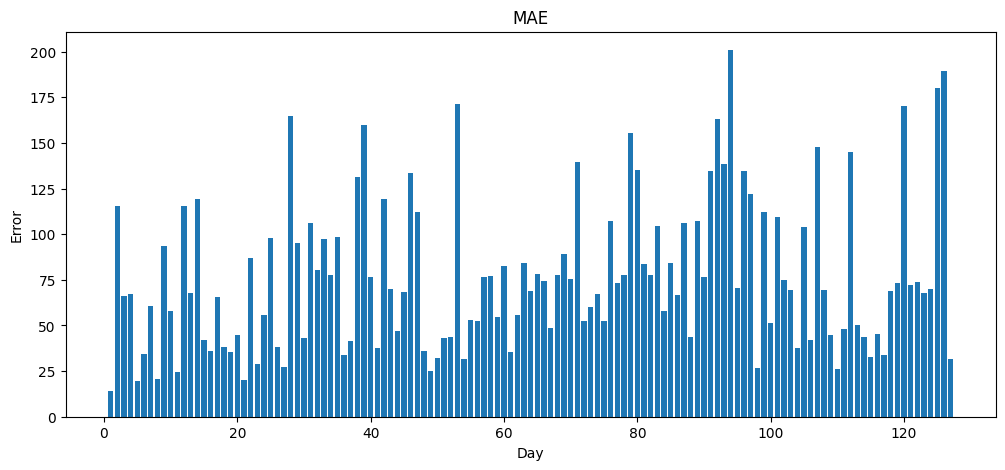

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_loss_POA1_v2)+1), real_loss_POA1_v2)
plt.title("MAE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

R2

In [ ]:
real_r2_POA1_v2=list_r2(yR_POA1_test,predict_POA1_p1_v2)
print(np.mean(real_r2_POA1_v2))

-29.08219298404539


In [ ]:
print(real_r2_POA1_v2)

[0.9057543711326697, -3130.431819363294, 0.3323917632970522, 0.4947252804055734, 0.9908137671840271, 0.8373140270357945, -0.7068919291214981, 0.9595651643412205, -0.3766784416338953, 0.9665100902067011, 0.968572763298726, -5.374901631289016, 0.8600348747381223, -34.844078123071256, -1.718544372497187, 0.9038281347140679, 0.5422765278946787, 0.9516638578865239, 0.9443604679974467, 0.9507183395537563, 0.9614718661595523, -2.788687426573284, 0.9847629732680261, 0.5175341363676214, 0.9112191732878993, 0.9031676809319911, -35.47212554513547, 0.4173252214856362, -3.4425598145519, 0.8186039798158462, 0.37676064570171863, -6.129180288496918, -37.72508924267919, 0.44695047059111725, -22.33092645558201, 0.6578169988827922, 0.9486431028058658, -16.899065797088692, -177.1712002222689, 0.24147094087911247, 0.9373705103647352, -10.068772372085858, 0.24817262561188336, 0.8558968262094764, -0.005583786889129305, -6.207890061662701, -1.748254886545701, 0.9547248786149527, 0.9651281558658691, 0.98696920

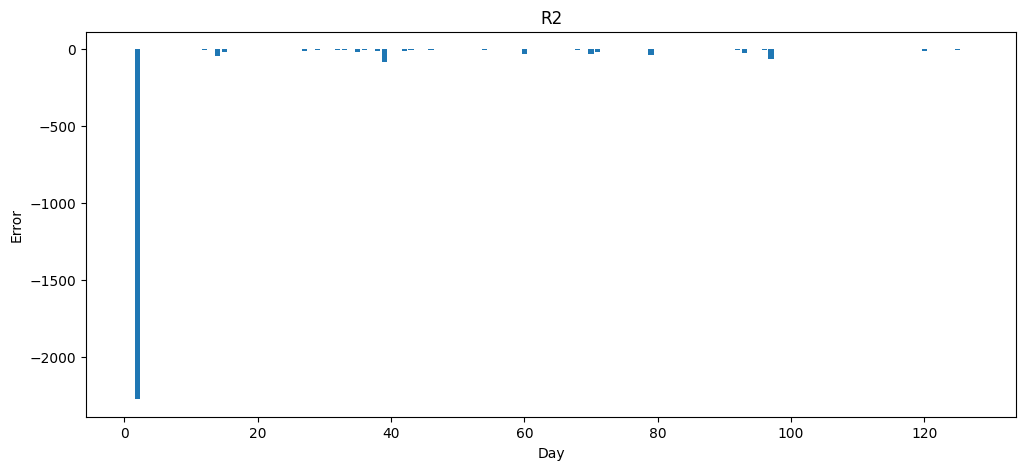

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_r2_POA1_v2)+1), real_r2_POA1_v2)
plt.title("R2")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

Mape

In [ ]:
real_mape_poa1_v2=mape_mod(yR_POA1_test,predict_POA1_p1_v2)
print(np.mean(real_mape_poa1_v2))

1.7162320721937898


In [ ]:
print(real_mape_poa1_v2)

[np.float64(0.5999176151525291), np.float64(41.51242781521021), np.float64(4.487668698090652), np.float64(1.059459927483696), np.float64(0.3095918238972898), np.float64(0.5515596979594504), np.float64(5.971328160357539), np.float64(0.43598506688400845), np.float64(1.1045074509073822), np.float64(0.36231144783732766), np.float64(0.20666135172106087), np.float64(2.619712865163347), np.float64(0.8305606181045283), np.float64(4.759387748830419), np.float64(2.4414483738410278), np.float64(0.5699829206727116), np.float64(1.1728259593027166), np.float64(0.5027261471427283), np.float64(0.2204661556410143), np.float64(0.45258872317273185), np.float64(0.3103263261934616), np.float64(1.4591579007059259), np.float64(0.22629691600714566), np.float64(0.7384008435315045), np.float64(0.465471294648799), np.float64(0.4525737926820873), np.float64(7.48726730545801), np.float64(0.6460175011220329), np.float64(3.3066367075808873), np.float64(0.37812798613670623), np.float64(0.5516312459868508), np.float64

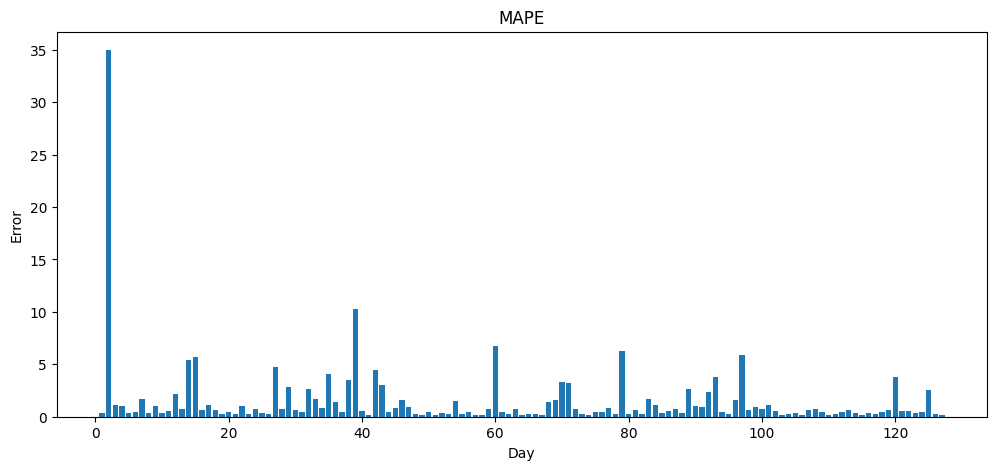

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_mape_poa1_v2)+1), real_mape_poa1_v2)
plt.title("MAPE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

Model summary

In [ ]:
model1_POA1_CNNGRU2_v2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 384, 10)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 384, 64)        │         3,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 384, 64)        │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 384, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 96)             │        46,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 96)             │         9,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 96)             │         9,312 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 267,266 (1.02 MB)

 Trainable params: 89,088 (348.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 178,178 (696.01 KB)

Check the graphs to understand atypical errors

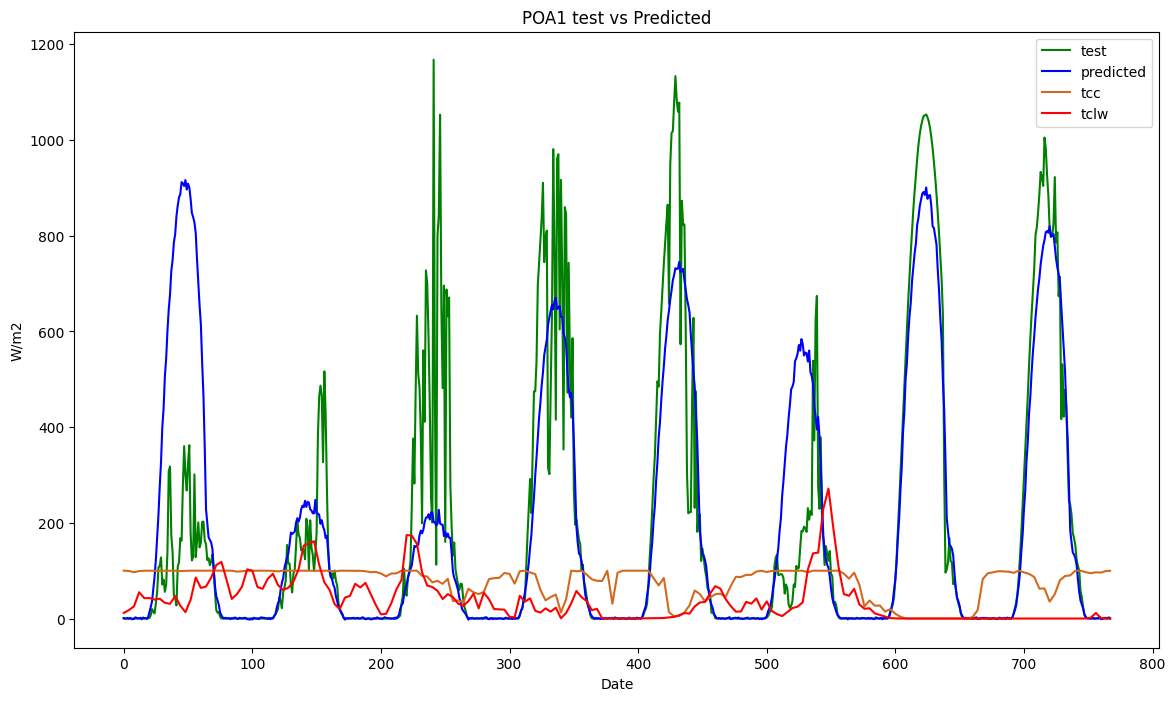

In [ ]:
plt.figure(figsize=(14,8))
st_day=120
end_day=130
dat_clouds=yR_POA1_test.shape[0]*yR_POA1_test.shape[1]
i_clouds=len(df3)-dat_clouds+(st_day-1)*96
f_clouds=i_clouds+(end_day-st_day)*96
plt.plot(yR_POA1_test.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='test',color='green')
plt.plot(predict_POA1_p1_v2.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='predicted',color='blue')
plt.plot(df3['tcc'].values[i_clouds:f_clouds],label='tcc',color='chocolate')
plt.plot(df3['tclw'].values[i_clouds:f_clouds]*300,label='tclw',color='red')
plt.title("POA1 test vs Predicted")
plt.xlabel("Date")
plt.ylabel("W/m2")
plt.legend()
plt.show()

CNN_GRU for POA2

Define callbacks

In [ ]:
check_point_poa2=ModelCheckpoint(filepath="model_checkpoint/best_model_poa2.keras",monitor='mae',save_best_only=True)

Define object tuner

In [ ]:
tuner_POA2=BayesianOptimization(create_model_tun_poa,objective='val_loss',max_trials=80,num_initial_points=16,alpha=1e-4,beta=2.6,project_name='cnn_gru2_tunv4_d2')

Reloading Tuner from ./cnn_gru2_tunv4_d2/tuner0.json


In [ ]:
tuner_POA2.search(X1_POA2_train,y1_POA2_train,epochs=40,validation_data=(X1_POA2_val,y1_POA2_val),callbacks=[early_stop1])
tuner_POA2.results_summary()

Results summary
Results in ./cnn_gru2_tunv4_d2
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 77 summary
Hyperparameters:
kernel_size: 5
filters: 64
dropout1: 0.2
units: 64
dropout2: 0.1
units_dense: 96
lr: 0.001
Score: 0.2419130653142929

Trial 34 summary
Hyperparameters:
kernel_size: 5
filters: 64
dropout1: 0.2
units: 32
dropout2: 0.1
units_dense: 64
lr: 0.001
Score: 0.2447631061077118

Trial 15 summary
Hyperparameters:
kernel_size: 3
filters: 32
dropout1: 0.2
units: 32
dropout2: 0.2
units_dense: 64
lr: 0.001
Score: 0.24531246721744537

Trial 41 summary
Hyperparameters:
kernel_size: 3
filters: 64
dropout1: 0.2
units: 96
dropout2: 0.1
units_dense: 96
lr: 0.0005
Score: 0.2453855276107788

Trial 33 summary
Hyperparameters:
kernel_size: 3
filters: 64
dropout1: 0.2
units: 96
dropout2: 0.2
units_dense: 96
lr: 0.0005
Score: 0.2456330955028534

Trial 58 summary
Hyperparameters:
kernel_size: 5
filters: 64
dropout1: 0.1
units: 64
dropout2: 0.2
units_dense: 64
lr: 0.0

Define the best model

In [ ]:
model1_POA2_CNNGRU2=tuner_POA2.get_best_models()[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 24 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
model1_POA2_CNNGRU2.save('/content/drive/MyDrive/Colab Notebooks/models_CNNGRU_RS/model_CNNGRU2_POA2_n5.keras')

In [ ]:
model1_POA2_CNNGRU2=keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/models_CNNGRU_RS/model_CNNGRU2_POA2_n5.keras')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Prediction and evaluation

In [ ]:

pred_POA2_p1=model1_POA2_CNNGRU2.predict(X1_POA2_test)
predict_POA2_p1=(scaler_POA2.inverse_transform(pred_POA2_p1.reshape(-1,1))).reshape(pred_POA2_p1.shape[0],pred_POA2_p1.shape[1])

1/4 ━━━━━━━━━━━━━━━━━━━━ 1s 371ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step


MAE

In [ ]:
real_loss_POA2=list_mae(yR_POA2_test,predict_POA2_p1)
print(np.mean(real_loss_POA2))

70.00446688780342


In [ ]:
print(real_loss_POA2)

[18.408800044436795, 68.54571962027192, 107.01291291688392, 63.94648294783527, 13.659364781359479, 35.75300464185617, 57.70364333857984, 22.475110538998536, 74.44880693819675, 21.02261869372636, 47.86485359825817, 96.4016452151446, 65.47518194000969, 139.83330530343105, 34.1375686972614, 86.33508758590898, 63.16475456049403, 66.26171085243813, 57.37524678621696, 34.4833949477586, 20.03211782178598, 46.45987215976183, 37.24762036673113, 58.22127259500269, 37.40299910007026, 22.76546406253317, 101.31484712419201, 147.96995975187158, 123.52389135906411, 43.75056687031522, 97.40636074977306, 125.52393641679089, 103.9237483827239, 99.15554252850318, 154.79948308646684, 22.7982995432765, 37.33679938567104, 162.09602054309318, 30.016877174005415, 36.08411288218733, 34.08603056218514, 64.49862398954701, 40.09883691331003, 43.500715827803226, 86.96711645861414, 124.3410987593602, 123.83694356807102, 39.858530039326084, 33.853797118897724, 59.47767971549439, 36.47152090834194, 50.87973936377151,

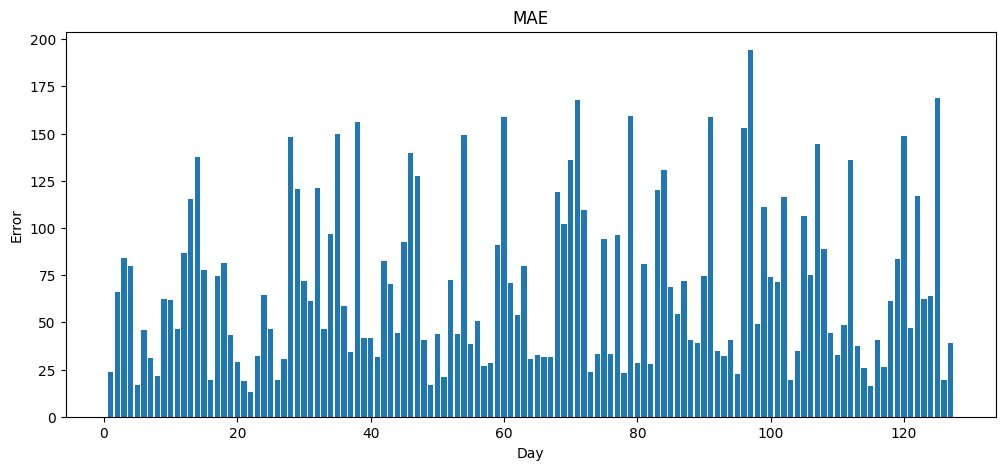

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_loss_POA2)+1), real_loss_POA2)
plt.title("MAE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

R2

In [ ]:
real_r2_POA2=list_r2(yR_POA2_test,predict_POA2_p1)
print(np.mean(real_r2_POA2))

-70.23210348604026


In [ ]:
print(real_r2_POA2)

[0.9701909545017035, -5200.424247746952, -0.1501526505942079, 0.6183788999324038, 0.9856052528743966, 0.8631946312445051, 0.0016604465364925547, 0.9549928601912312, -2.1390872020654452, 0.97507073367788, 0.8861853209745778, -6.745885235145376, 0.776714722358006, -53.187275208273356, -6.724850323895948, 0.6727456336584561, 0.6121917128056285, 0.7928626870483735, 0.8023628512410498, 0.942507366263105, 0.9743771327110252, -0.7970802496668874, 0.9492147424206845, 0.696806806661347, 0.9019292307756714, 0.9718493661963683, -95.52308164724752, 0.14151727202913222, -3.354415100605741, 0.7987877910246732, 0.49009058554372564, -5.33753813972509, -30.40102225177597, 0.35406223315016894, -18.874811747923065, 0.7567967410858503, 0.9370293371510247, -17.338404671713974, -3322.366495946941, 0.36167635187539404, 0.9643473934807872, -1.864888041164651, -1.0712098513745505, 0.8911312279320217, 0.2994429404364036, -4.770015920636108, -1.9394301231035342, 0.9453216575781375, 0.9698489108127596, 0.90732268

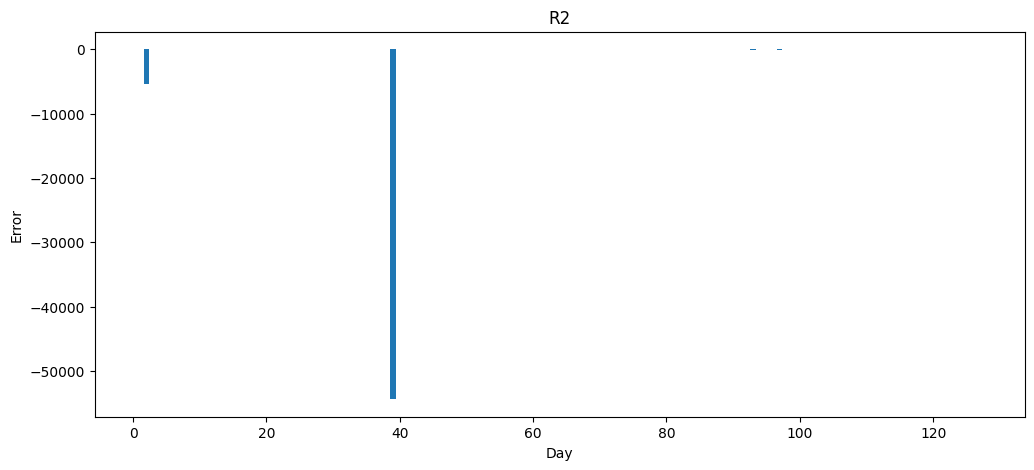

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_r2_POA2)+1), real_r2_POA2)
plt.title("R2")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

MAPE

In [ ]:
real_mape_poa2=mape_mod(yR_POA2_test,predict_POA2_p1)
print(np.mean(real_mape_poa2))

nan


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
print(real_mape_poa2)

[np.float64(0.2648606830312313), np.float64(32.73023645622642), np.float64(6.812170031527915), np.float64(0.8786387708947365), np.float64(0.18180290623816964), np.float64(0.4727465109058988), np.float64(7.263092583929333), np.float64(0.3828200650198595), np.float64(1.602156478731711), np.float64(0.23629088214369268), np.float64(0.2939261500452288), np.float64(2.7119410985223675), np.float64(0.7735947828269049), np.float64(5.853642465183523), np.float64(3.100512254435531), np.float64(0.41765628779227076), np.float64(0.925898953723687), np.float64(0.3826555211859609), np.float64(0.3721893000671144), np.float64(0.3937948266020209), np.float64(0.2256833193912972), np.float64(0.9358097010004596), np.float64(0.23644483725422902), np.float64(0.6742485939363765), np.float64(0.3414760286009453), np.float64(0.22558236829793352), np.float64(12.673820114261293), np.float64(0.647542165727362), np.float64(3.0647966590246796), np.float64(0.41057047293625476), np.float64(0.5056020612388338), np.float6

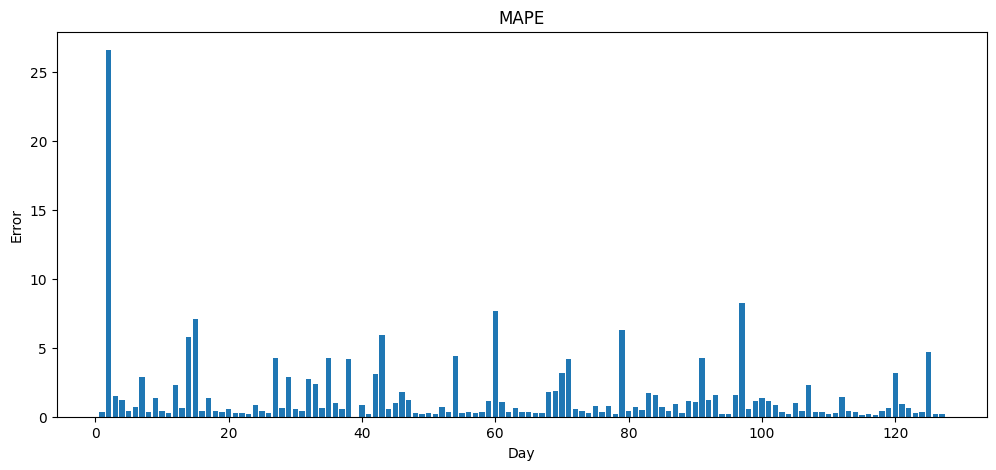

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_mape_poa2)+1), real_mape_poa2)
plt.title("MAPE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

In [ ]:
model1_POA2_CNNGRU2.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 384, 10)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 384, 64)        │         3,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 384, 64)        │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 384, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 96)             │         6,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 96)             │         9,312 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,320 (251.25 KB)

 Trainable params: 64,320 (251.25 KB)

 Non-trainable params: 0 (0.00 B)

Check the graphs to understand atypical errors

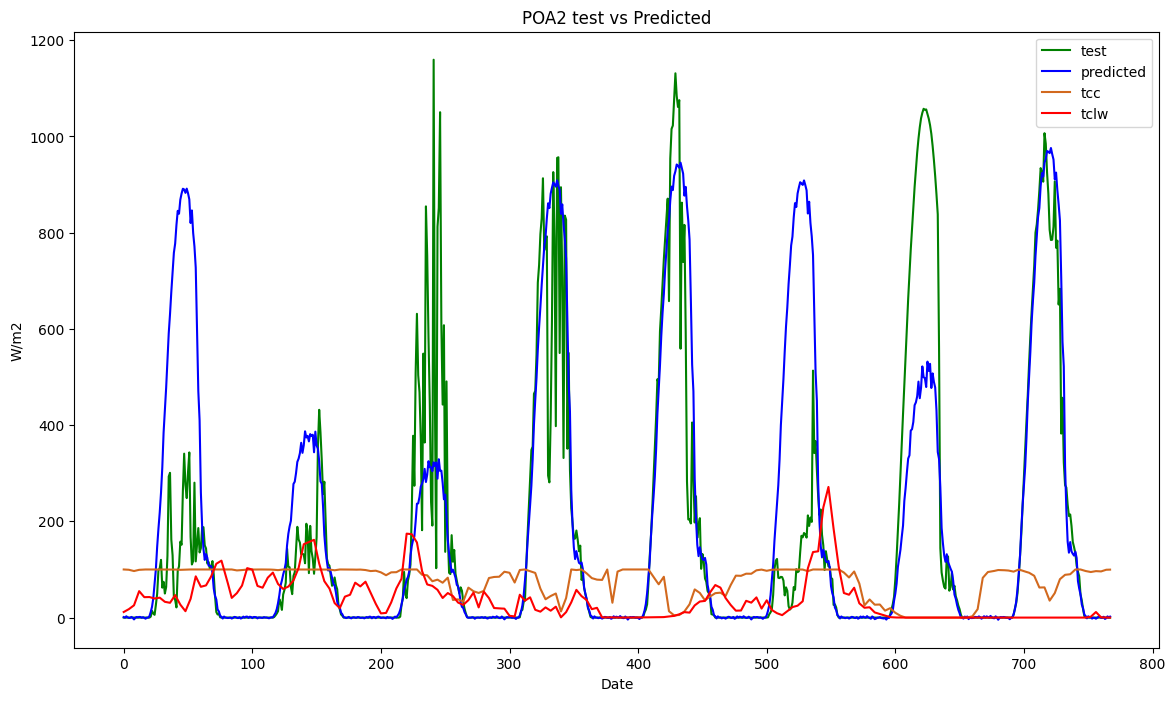

In [ ]:
plt.figure(figsize=(14,8))
st_day=120
end_day=130
dat_clouds=yR_POA2_test.shape[0]*yR_POA2_test.shape[1]
i_clouds=len(df3)-dat_clouds+(st_day-1)*96
f_clouds=i_clouds+(end_day-st_day)*96
plt.plot(yR_POA2_test.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='test',color='green')
plt.plot(predict_POA2_p1.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='predicted',color='blue')
plt.plot(df3['tcc'].values[i_clouds:f_clouds],label='tcc',color='chocolate')
plt.plot(df3['tclw'].values[i_clouds:f_clouds]*300,label='tclw',color='red')
plt.title("POA2 test vs Predicted")
plt.xlabel("Date")
plt.ylabel("W/m2")
plt.legend()
plt.show()

Retraining in case you need it

In [ ]:
X1_POA2_train=np.concatenate((X1_POA2_train,X1_POA2_val),axis=0)
y1_POA2_train=np.concatenate((y1_POA2_train,y1_POA2_val),axis=0)

print(X1_POA2_train.shape)
print(y1_POA2_train.shape)

(1133, 384, 10)
(1133, 96)


In [ ]:
model1_POA2_CNNGRU2_v2=create_model_poa(X1_POA2_train,y1_POA2_train,70,0.001,check_point_poa2)

Epoch 1/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.8119 - mae: 0.8119 - mape: 30010960.0000 - mse: 2.4546
Epoch 2/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.4464 - mae: 0.4464 - mape: 51208964.0000 - mse: 0.6090
Epoch 3/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.3916 - mae: 0.3916 - mape: 35898784.0000 - mse: 0.5482
Epoch 4/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.3754 - mae: 0.3754 - mape: 30273704.0000 - mse: 0.5234
Epoch 5/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.3621 - mae: 0.3621 - mape: 26299510.0000 - mse: 0.5070
Epoch 6/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.3498 - mae: 0.3498 - mape: 22506170.0000 - mse: 0.4943
Epoch 7/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.3433 - mae: 0.3433 - mape: 20035386.0000 - mse: 0.4814
Epoch 8/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.3407 - mae: 0.3407 - mape: 17929336.0000 - mse: 0.4822
Epoch 9/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.3352 - mae:

In [ ]:
model1_POA2_CNNGRU2_v2=load_model("model_checkpoint/best_model_poa2.keras")

Save the model

In [ ]:
model1_POA2_CNNGRU2_v2.save('/content/drive/MyDrive/Colab Notebooks/models_CNNGRU_RS/model_CNNGRU2_POA2_n5_v2.keras')

In [ ]:
model1_POA2_CNNGRU2_v2=keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/models_CNNGRU_RS/model_CNNGRU2_POA2_n5_v2.keras')

Prediction and evaluation

In [ ]:
pred_POA2_p1_v2=model1_POA2_CNNGRU2_v2.predict(X1_POA2_test)
predict_POA2_p1_v2=(scaler_POA2.inverse_transform(pred_POA2_p1_v2.reshape(-1,1))).reshape(pred_POA2_p1_v2.shape[0],pred_POA2_p1_v2.shape[1])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


MAE

In [ ]:
real_loss_POA2_v2=list_mae(yR_POA2_test,predict_POA2_p1_v2)
print(np.mean(real_loss_POA2_v2))

78.45421359626758


In [ ]:
print(real_loss_POA2_v2)

[19.963448530163237, 100.40405601838317, 84.88936961535298, 66.35561228986693, 24.586342032005632, 32.41233066324373, 27.981974394550605, 50.28826169105236, 89.68470541973159, 33.580204843328055, 67.63830582737248, 29.404232801788122, 49.39495036423491, 151.1847148638844, 21.649888479488464, 36.5604651702243, 63.464380645741834, 23.715964150377705, 86.64599033388545, 52.92197654778578, 21.378615437383647, 9.156187941464966, 22.560587885999766, 56.66813939604572, 36.72929345234899, 25.46934054388332, 82.20506784168018, 125.82361363177831, 103.40335229131354, 42.52424465928606, 51.66491697890415, 135.56293489431098, 132.37566947062703, 125.102576146201, 152.18355303566133, 16.849496094417244, 73.17861242923782, 174.903969390768, 23.09131620666838, 41.601555649310065, 37.381235944712095, 31.43207499416827, 19.05877591635666, 44.97391648126368, 115.68505611463131, 170.16544757966082, 105.7974906947042, 26.602750131703587, 35.55950397563217, 75.3603505316886, 19.695218886988837, 96.62341636

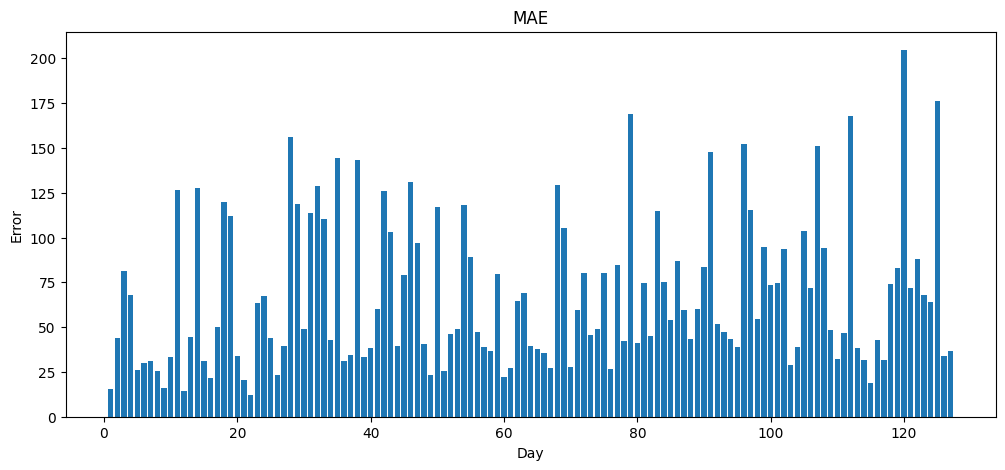

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_loss_POA2_v2)+1), real_loss_POA2_v2)
plt.title("MAE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

R2

In [ ]:
real_r2_POA2_v2=list_r2(yR_POA2_test,predict_POA2_p1_v2)
print(np.mean(real_r2_POA2_v2))

-116.58093089442572


In [ ]:
print(real_r2_POA2_v2)

[0.9610347206513662, -11738.970004879066, 0.20360771213256623, 0.5429058507148363, 0.9735274006647606, 0.8800455036030478, 0.6110405433914654, 0.8668647436394394, -3.608034717860221, 0.9490341028430344, 0.776254760343615, 0.268307399275885, 0.8848280240120051, -62.85006368829239, -2.184061751360715, 0.93709454530572, 0.5835792863808977, 0.963257389696082, 0.5282898702430943, 0.8656597773085838, 0.9716785712005872, 0.925086539774531, 0.9793540328267629, 0.6688625229674936, 0.9059196829269197, 0.9637463488471658, -62.344223963824355, 0.4216249007956814, -2.0946084350857403, 0.7998304309382223, 0.8536732851506353, -6.254599460111886, -54.26067347113289, 0.01384074702387339, -18.216038584487503, 0.8356523485008793, 0.7521144355212623, -20.19806236689869, -2537.188111797387, 0.1720374883280229, 0.9611996753333647, 0.4203722974298967, 0.3659277519473506, 0.8995133784092059, -0.25647764677640694, -9.670278437497963, -1.0717601651307858, 0.9579385902000123, 0.9496895893738863, 0.84733895349113

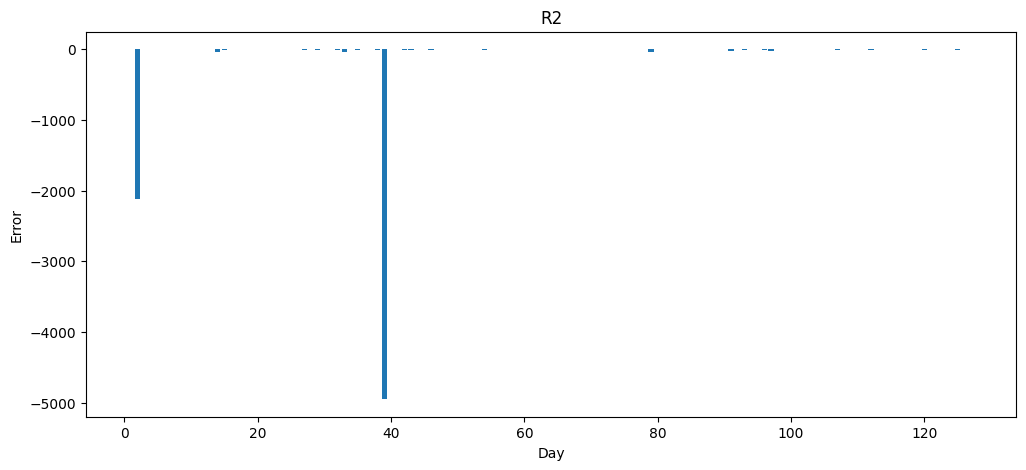

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_r2_POA2_v2)+1), real_r2_POA2_v2)
plt.title("R2")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

MAPE

In [ ]:
real_mape_poa2_v2=mape_mod(yR_POA2_test,predict_POA2_p1_v2)
print(np.mean(real_mape_poa2_v2))

nan


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
print(real_mape_poa2_v2)

[np.float64(0.17393539392017354), np.float64(49.65246353061775), np.float64(5.48727432715199), np.float64(0.9080620919907505), np.float64(0.18893700242930966), np.float64(0.44518294830019156), np.float64(2.9590245233027552), np.float64(0.3606306816224642), np.float64(1.8648836942011657), np.float64(0.20846928576043255), np.float64(0.37234619916411976), np.float64(1.039823670832894), np.float64(0.7962172464970672), np.float64(6.312553765037156), np.float64(2.0994723534742934), np.float64(0.206299724691054), np.float64(0.9097049599620062), np.float64(0.38659099064476826), np.float64(0.4967309581053101), np.float64(0.38262144652430913), np.float64(0.21399616258212759), np.float64(0.21304472560547177), np.float64(0.16322034586522757), np.float64(0.6383484214584995), np.float64(0.33167632202754005), np.float64(0.21637071335326108), np.float64(10.630724837618864), np.float64(0.6857447825400954), np.float64(2.8264622703281006), np.float64(0.38002315497777417), np.float64(0.3456237864153972), 

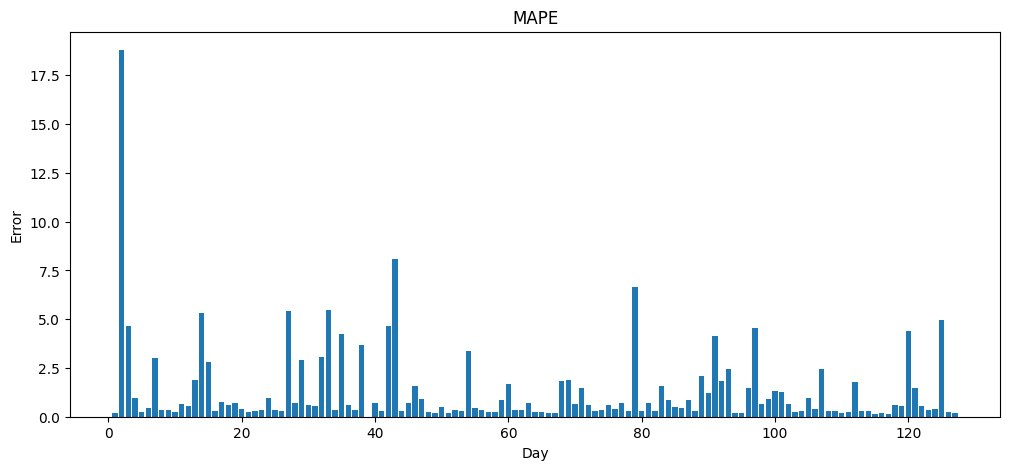

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_mape_poa2_v2)+1), real_mape_poa2_v2)
plt.title("MAPE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

Check the graphs to understand atypical errors

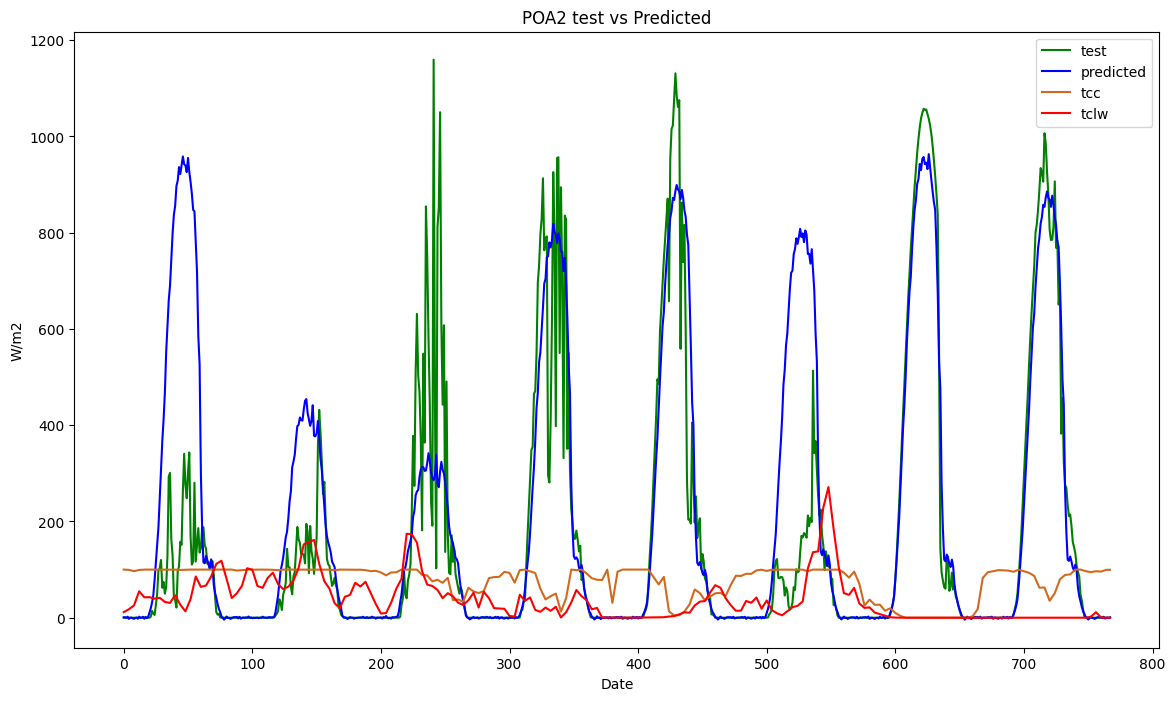

In [ ]:
plt.figure(figsize=(14,8))
st_day=120
end_day=130
dat_clouds=yR_POA2_test.shape[0]*yR_POA2_test.shape[1]
i_clouds=len(df3)-dat_clouds+(st_day-1)*96
f_clouds=i_clouds+(end_day-st_day)*96
plt.plot(yR_POA2_test.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='test',color='green')
plt.plot(predict_POA2_p1_v2.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='predicted',color='blue')
plt.plot(df3['tcc'].values[i_clouds:f_clouds],label='tcc',color='chocolate')
plt.plot(df3['tclw'].values[i_clouds:f_clouds]*300,label='tclw',color='red')
plt.title("POA2 test vs Predicted")
plt.xlabel("Date")
plt.ylabel("W/m2")
plt.legend()
plt.show()

Model summary

In [ ]:
model1_POA2_CNNGRU2_v2.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 384, 10)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 384, 64)        │         3,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 384, 64)        │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 384, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 96)             │         6,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 96)             │         9,312 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 192,962 (753.76 KB)

 Trainable params: 64,320 (251.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 128,642 (502.51 KB)

Visualize Prediction vs Real data

Create model for retraining Rear side

In [ ]:
def create_model_tun_rear(hp):

  seq_input=keras.layers.Input(shape=(obs_window,9+n_exo_var),name='seq-input')

  x=seq_input
  kernel_size1=hp.Choice('kernel_size',[3,5])
  filters1=hp.Choice('filters',[32,64])

  x=keras.layers.Conv1D(filters=filters1,kernel_size=kernel_size1,activation='relu',padding='same')(x)
  x=keras.layers.Conv1D(filters=filters1,kernel_size=kernel_size1,activation='relu',padding='same')(x)

  x=keras.layers.Dropout(hp.Choice('dropout1',[0.1, 0.2]))(x)

  x=keras.layers.GRU(units=hp.Choice('units',[32,64,96]),return_sequences=False)(x)
  x=keras.layers.Dropout(hp.Choice('dropout2',[0.1, 0.2]))(x)
  x=keras.layers.Dense(units=hp.Choice('units_dense',[64,96]),activation='relu')(x)

  surf_input=keras.layers.Input(shape=(4,),name='surf-input')
  s=keras.layers.Dense(32,activation='relu')(surf_input)

  comb=Concatenate()([x,s])
  comb=keras.layers.Dense(units=hp.Choice('dense-mid',[96,128]),activation='relu')(comb)

  output=keras.layers.Dense(win_size)(comb)
  model=keras.models.Model(inputs=[seq_input, surf_input],outputs=output)

  model.compile(optimizer=Adam(hp.Choice('lr',[1e-3,5e-4])),loss='mae',metrics=['mae','mse','mape'])
  return model

In [ ]:
def create_model_rear(X,y,epochs,learning_rate1,cb):
  seq_input=keras.layers.Input(shape=(obs_window,9+n_exo_var),name='seq-input')

  x=seq_input
  kernel_size1=3
  filters1=32

  x=keras.layers.Conv1D(filters=filters1,kernel_size=kernel_size1,activation='relu',padding='same')(x)
  x=keras.layers.Conv1D(filters=filters1,kernel_size=kernel_size1,activation='relu',padding='same')(x)

  x=keras.layers.Dropout(0.1)(x)

  x=keras.layers.GRU(units=32,return_sequences=False)(x)
  x=keras.layers.Dropout(0.1)(x)

  x=keras.layers.Dense(units=64,activation='relu')(x)

  surf_input=keras.layers.Input(shape=(4,),name='surf-input')
  s=keras.layers.Dense(32,activation='relu')(surf_input)

  comb=Concatenate()([x,s])
  comb=keras.layers.Dense(units=96,activation='relu')(comb)

  output=keras.layers.Dense(win_size)(comb)
  model=keras.models.Model(inputs=[seq_input, surf_input],outputs=output)

  model.compile(optimizer=Adam(learning_rate=learning_rate1),loss='mae',metrics=['mae','mse','mape'])
  model.fit(X,y,epochs=epochs,callbacks=[cb])
  return model

CNNGRU for REAR 1

Define callbacks

In [ ]:
check_point_rear1=ModelCheckpoint(filepath="model_checkpoint/best_model_rear1.keras",monitor='mae',save_best_only=True)

Define object tuner

In [ ]:
tuner_Rear1=BayesianOptimization(create_model_tun_rear,objective='val_loss',max_trials=90,num_initial_points=18,alpha=1e-4,beta=2.6,project_name='cnn_gru2_tunv4_d3')

In [ ]:
tuner_Rear1.search([X1_Rear1_train,surf_Rear1_train],y1_Rear1_train,epochs=40,validation_data=([X1_Rear1_val,surf_Rear1_val],y1_Rear1_val),callbacks=[early_stop1])
tuner_Rear1.results_summary()

Trial 90 Complete [00h 00m 22s]
val_loss: 0.1959812492132187

Best val_loss So Far: 0.17923463881015778
Total elapsed time: 00h 42m 05s
Results summary
Results in ./cnn_gru2_tunv4_d3
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 40 summary
Hyperparameters:
kernel_size: 3
filters: 32
dropout1: 0.2
units: 96
dropout2: 0.2
units_dense: 64
dense-mid: 128
lr: 0.001
Score: 0.17923463881015778

Trial 52 summary
Hyperparameters:
kernel_size: 5
filters: 32
dropout1: 0.2
units: 32
dropout2: 0.1
units_dense: 64
dense-mid: 128
lr: 0.001
Score: 0.18172116577625275

Trial 65 summary
Hyperparameters:
kernel_size: 3
filters: 64
dropout1: 0.1
units: 96
dropout2: 0.2
units_dense: 96
dense-mid: 96
lr: 0.001
Score: 0.1819968819618225

Trial 51 summary
Hyperparameters:
kernel_size: 3
filters: 32
dropout1: 0.2
units: 64
dropout2: 0.1
units_dense: 96
dense-mid: 96
lr: 0.001
Score: 0.18284538388252258

Trial 68 summary
Hyperparameters:
kernel_size: 5
filters: 32
dropout1: 0.1
units

Define the best model

In [ ]:
model1_Rear1_CNNGRU2=tuner_Rear1.get_best_models()[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 32 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
model1_Rear1_CNNGRU2.save('/content/drive/MyDrive/Colab Notebooks/models_CNNGRU_RS/model_CNNGRU2_Rear1_n5.keras')

In [ ]:
model1_Rear1_CNNGRU2=keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/models_CNNGRU_RS/model_CNNGRU2_Rear1_n5.keras')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 30 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Prediction and evaluation

In [ ]:

pred_Rear1_p1=model1_Rear1_CNNGRU2.predict([X1_Rear1_test,surf_Rear1_test])
predict_Rear1_p1=(scaler_Rear1.inverse_transform(pred_Rear1_p1.reshape(-1,1))).reshape(pred_Rear1_p1.shape[0],pred_Rear1_p1.shape[1])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


MAE

In [ ]:
real_loss_Rear1=list_mae(yR_Rear1_test,predict_Rear1_p1)
print(np.mean(real_loss_Rear1))

8.060300022515856


In [ ]:
print(real_loss_Rear1)

[2.390379072365355, 10.41112540922492, 28.25027283267728, 14.936288227141333, 15.659285497405426, 9.444921407874073, 12.258203991007747, 10.546080847881786, 2.492278376499789, 7.26757249040345, 6.480171160790721, 3.6694223592690762, 10.691104864224522, 7.403826356617547, 5.5225758079101155, 44.15535241129146, 15.459389555993786, 20.122632927817424, 16.685157638868795, 11.312081486268978, 10.007916652595755, 2.053955951371881, 8.876782061424835, 4.730737809544952, 6.311630133911848, 5.094489963375639, 6.0958259274512985, 10.579066183848639, 6.277356524172273, 4.363549150419099, 8.588599430861537, 5.548348141282133, 4.243049924455523, 8.288978113160667, 8.378628973512672, 2.368389726006002, 7.262875988463885, 8.892135036876153, 6.8906255988548635, 3.6357068561760566, 8.749772742305638, 7.491173567531945, 5.677461386492516, 6.098820897932353, 6.997401184348042, 10.86095341047325, 5.277156503467244, 6.372936244950009, 3.679374188712146, 10.989524698592069, 5.327800281201308, 4.409589375241

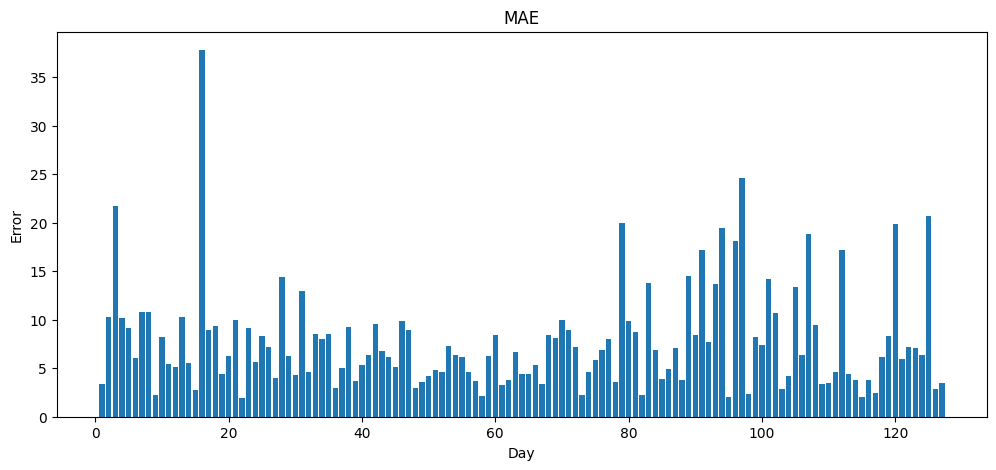

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_loss_Rear1)+1), real_loss_Rear1)
plt.title("MAE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

R2

In [ ]:
real_r2_Rear1=list_r2(yR_Rear1_test,predict_Rear1_p1)
print(np.mean(real_r2_Rear1))

-2.702190319276253


In [ ]:
print(real_r2_Rear1)

[0.958957953699087, 0.35911817946364855, 0.1930041339146611, 0.4062340393726058, 0.5085734813361011, 0.6882433261143763, 0.2919752847739936, 0.5705514866656709, 0.8026045665492952, 0.6848611084640771, 0.7329001095310291, 0.3293864986383267, 0.3648947982105354, -16.75630633715714, -34.953098168990216, -0.05875334966247192, 0.5286551696318891, 0.27737270574358663, 0.3764274111417736, 0.6155760998068516, 0.6603725472481988, 0.9085969753002042, 0.6605174648490257, 0.7938045321118503, 0.7333163116449675, 0.8354502466475378, -85.92340304640479, 0.3536039071584537, 0.1533730796023609, 0.7101664406171886, 0.5161723890454729, -0.2633972094453443, -9.58454200742694, 0.45384900628715485, -3.440930118485273, 0.7661314910574062, 0.7037319919379116, -2.7461515054183154, 0.4647521748414495, 0.3575198422388669, 0.7122604714153054, -1.4485849993480993, -5.537130969863993, 0.8207623486168345, 0.4953392477523185, -2.3338234402247884, 0.6293382300636192, 0.78748020244751, 0.955398961471223, 0.592765978795

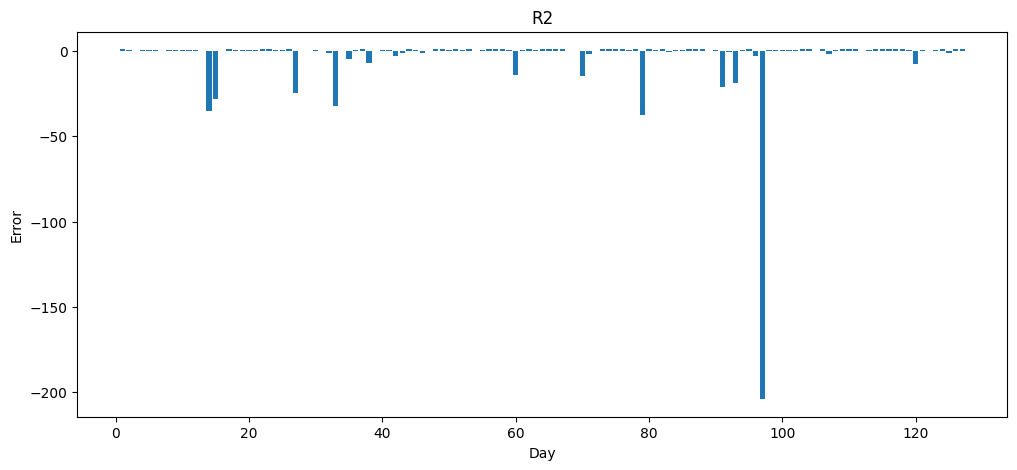

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_r2_Rear1)+1),real_r2_Rear1)
plt.title("R2")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

MAPE

In [ ]:
real_mape_Rear1=mape_mod(yR_Rear1_test,predict_Rear1_p1)
print(np.mean(real_mape_Rear1))

0.8542777234251254


In [ ]:
print(real_mape_Rear1)

[np.float64(0.18788151598538633), np.float64(0.495715692118357), np.float64(0.7249512386828236), np.float64(0.5012689837430048), np.float64(0.5673089017425794), np.float64(0.4262098840054638), np.float64(0.6475852758871177), np.float64(0.5420044721879549), np.float64(0.4051160974310155), np.float64(0.47654060462297365), np.float64(0.4340562196566423), np.float64(0.6964307384909686), np.float64(0.634750314155177), np.float64(3.119762060819069), np.float64(2.230476248985154), np.float64(0.8558676239197885), np.float64(0.5110140084008061), np.float64(0.6828966506245823), np.float64(0.662715855467531), np.float64(0.4820602024571379), np.float64(0.48078865255015507), np.float64(0.24049794384662893), np.float64(0.511637176749292), np.float64(0.48855797882595753), np.float64(0.46137432995710315), np.float64(0.3275155463832871), np.float64(3.6810763915413887), np.float64(0.679088635741428), np.float64(0.9038143240804187), np.float64(0.35468513535852564), np.float64(0.5349967990050357), np.floa

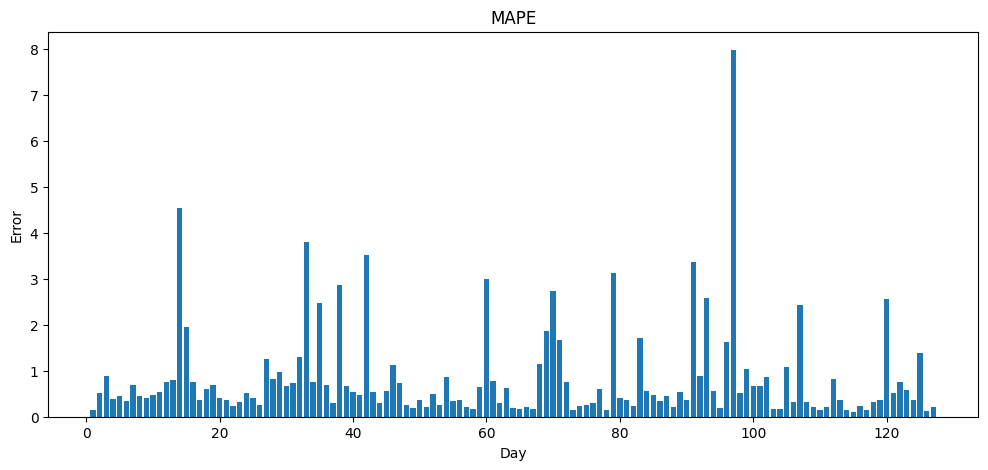

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_mape_Rear1)+1), real_mape_Rear1)
plt.title("MAPE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

Check the graphs to understand atypical errors

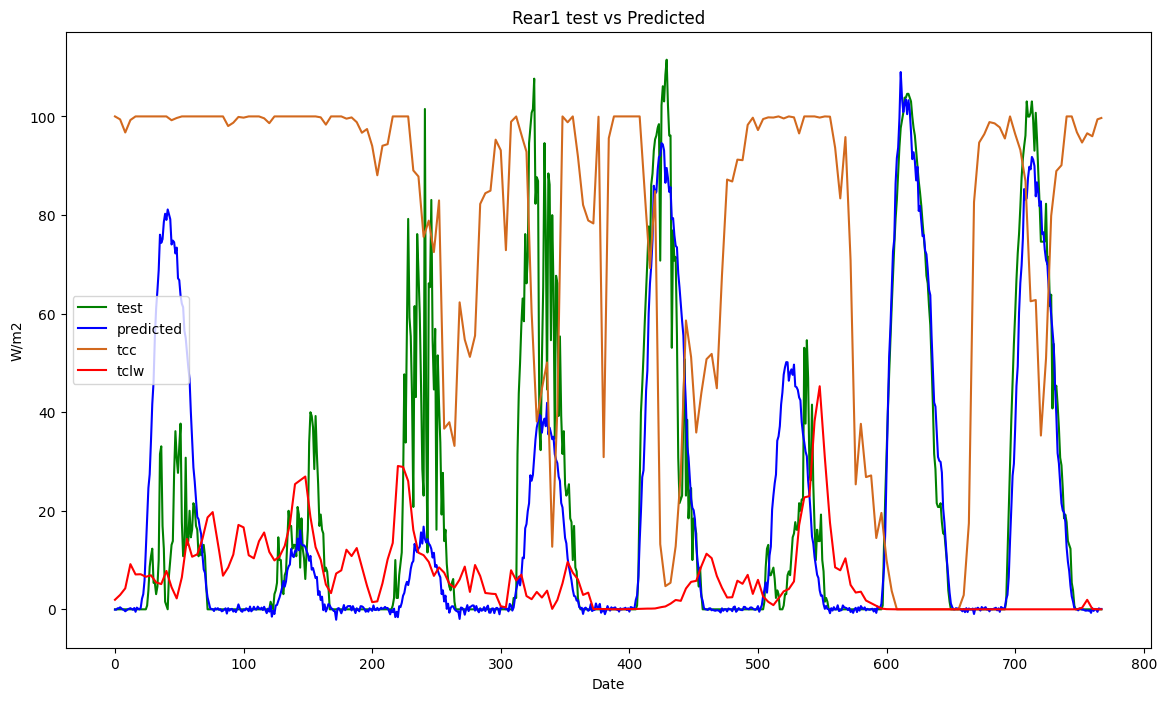

In [ ]:
plt.figure(figsize=(14,8))
st_day=120
end_day=130
dat_clouds=yR_Rear1_test.shape[0]*yR_Rear1_test.shape[1]
i_clouds=len(df3)-dat_clouds+(st_day-1)*96
f_clouds=i_clouds+(end_day-st_day)*96
plt.plot(yR_Rear1_test.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='test',color='green')
plt.plot(predict_Rear1_p1.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='predicted',color='blue')
plt.plot(df3['tcc'].values[i_clouds:f_clouds],label='tcc',color='chocolate')
plt.plot(df3['tclw'].values[i_clouds:f_clouds]*50,label='tclw',color='red')
plt.title("Rear1 test vs Predicted")
plt.xlabel("Date")
plt.ylabel("W/m2")
plt.legend()
plt.show()

In [ ]:
model1_Rear1_CNNGRU2.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq-input           │ (None, 384, 14)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 384, 32)   │      1,376 │ seq-input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 384, 32)   │      3,104 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 384, 32)   │          0 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 96)        │     37,440 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 96)        │          0 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ surf-input          │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      6,208 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        160 │ surf-input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     12,416 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 96)        │     12,384 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 73,088 (285.50 KB)

 Trainable params: 73,088 (285.50 KB)

 Non-trainable params: 0 (0.00 B)

Retraining in case you need it

In [ ]:
X1_Rear1_train=np.concatenate((X1_Rear1_train,X1_Rear1_val),axis=0)
y1_Rear1_train=np.concatenate((y1_Rear1_train,y1_Rear1_val),axis=0)
surf_Rear1_train=np.concatenate((surf_Rear1_train,surf_Rear1_val),axis=0)

print(X1_Rear1_train.shape)
print(y1_Rear1_train.shape)
print(surf_Rear1_train.shape)

(1133, 384, 14)
(1133, 96)
(1133, 4)


In [ ]:
model1_Rear1_CNNGRU2_v2=create_model_rear([X1_Rear1_train,surf_Rear1_train],y1_Rear1_train,70,0.001,check_point_rear1)

Epoch 1/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.6192 - mae: 0.6192 - mape: 13622463.0000 - mse: 1.4096
Epoch 2/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.3353 - mae: 0.3353 - mape: 14638171.0000 - mse: 0.4107
Epoch 3/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.3019 - mae: 0.3019 - mape: 10405102.0000 - mse: 0.3463
Epoch 4/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.2895 - mae: 0.2895 - mape: 8561607.0000 - mse: 0.3308
Epoch 5/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.2742 - mae: 0.2742 - mape: 7279483.5000 - mse: 0.3016
Epoch 6/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.2692 - mae: 0.2692 - mape: 6435479.0000 - mse: 0.2952
Epoch 7/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.2619 - mae: 0.2619 - mape: 5786017.5000 - mse: 0.2851
Epoch 8/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.2638 - mae: 0.2638 - mape: 5439735.0000 - mse: 0.2904
Epoch 9/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.2552 - mae: 0.25

In [ ]:
model1_Rear1_CNNGRU2_v2=load_model("model_checkpoint/best_model_rear1.keras")

Save the model

In [ ]:
model1_Rear1_CNNGRU2_v2.save('/content/drive/MyDrive/Colab Notebooks/models_CNNGRU_RS/model_CNNGRU2_Rear1_n5_v2.keras')

In [ ]:
model1_Rear1_CNNGRU2_v2=keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/models_CNNGRU_RS/model_CNNGRU2_Rear1_n5_v2.keras')

Prediction and evaluation

In [ ]:
pred_Rear1_p1_v2=model1_Rear1_CNNGRU2_v2.predict([X1_Rear1_test,surf_Rear1_test])
predict_Rear1_p1_v2=(scaler_Rear1.inverse_transform(pred_Rear1_p1_v2.reshape(-1,1))).reshape(pred_Rear1_p1_v2.shape[0],pred_Rear1_p1_v2.shape[1])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


MAE

In [ ]:
real_loss_Rear1_v2=list_mae(yR_Rear1_test,predict_Rear1_p1_v2)
print(np.mean(real_loss_Rear1_v2))

9.298168076068276


In [ ]:
print(real_loss_Rear1_v2)

[1.4718570144199858, 11.881694069250399, 23.688624255850005, 17.43486001288697, 12.0546649730463, 6.966291472818188, 12.80230438194089, 4.036060566358465, 3.4624295708825734, 1.4115976379186723, 9.907508740301328, 9.692885290869404, 8.802000479902048, 13.051250865337167, 4.537146259400693, 40.973888156860205, 6.7591359503479564, 24.25619018491794, 21.232755321907515, 5.630558925604761, 4.438560154678761, 4.69771116588305, 7.466974598513157, 4.8183925383056, 3.056276587442378, 3.18299580523302, 4.553360081272335, 11.148377417783271, 10.080123776542644, 3.5318974602642617, 10.405965750264466, 11.648805480695406, 17.858975506601862, 10.127964766527578, 15.187470221710262, 13.66453257470444, 2.421983903857259, 15.938138443227842, 8.944424763234602, 2.865854644194036, 14.375384026043903, 11.202831106283275, 2.223674572066252, 14.147083528270867, 3.361185526216543, 3.269756023971763, 12.800155746528773, 11.153377855335357, 3.925528564118802, 13.25336979541374, 8.226402895702146, 6.8417810013

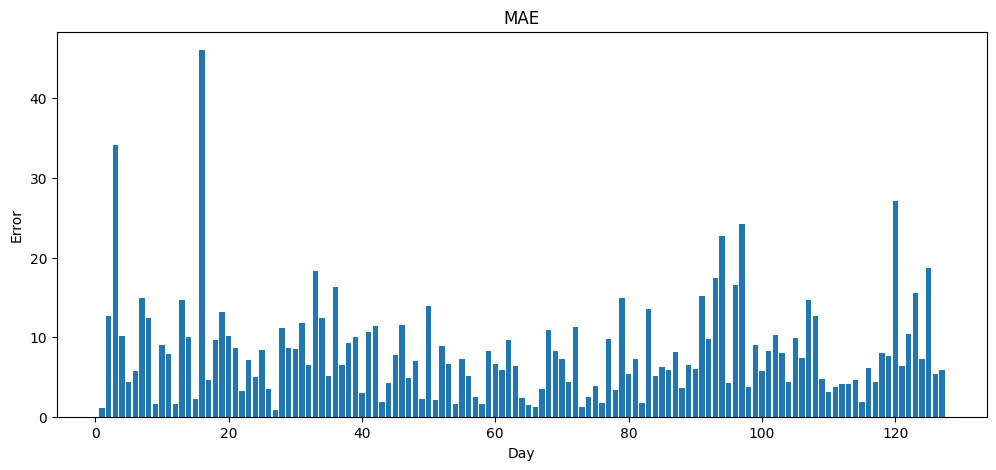

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_loss_Rear1_v2)+1), real_loss_Rear1_v2)
plt.title("MAE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

R2

In [ ]:
real_r2_Rear1_v2=list_r2(yR_Rear1_test,predict_Rear1_p1_v2)
print(np.mean(real_r2_Rear1_v2))

-6.583903450509833


In [ ]:
print(real_r2_Rear1_v2)

[0.9723357261236292, 0.2342898606170527, 0.449069266105267, 0.3005000994880893, 0.7128962099884444, 0.8115818544486046, 0.21204199445941063, 0.9132859528769378, 0.5306980634464554, 0.9853609360604875, 0.32976802862717935, -4.508216318750011, 0.49370920300411125, -60.97569369525625, -28.614385424052813, 0.0752288852201819, 0.9314029992000068, -0.04418554467819957, -0.044183489230793294, 0.9065776407726389, 0.9166569070349074, 0.4023398803044914, 0.7444621896925965, 0.6727427093785654, 0.9020102578320883, 0.9330302177989309, -56.37869022365938, 0.25460645627744505, -1.511933914944255, 0.7738863529627449, 0.2662770825200307, -4.309585215192608, -224.58668426764063, 0.17829030313207328, -14.837437923462485, -7.876395910345995, 0.9614832607576438, -12.325328251660782, 0.09264865899566144, 0.4144220186436409, 0.15435174723131917, -5.272951274860338, -0.1309464373210505, 0.017632197569205532, 0.8871037783472739, 0.6442577365100113, -1.4059338640856112, 0.41796634030478785, 0.9279250515908428,

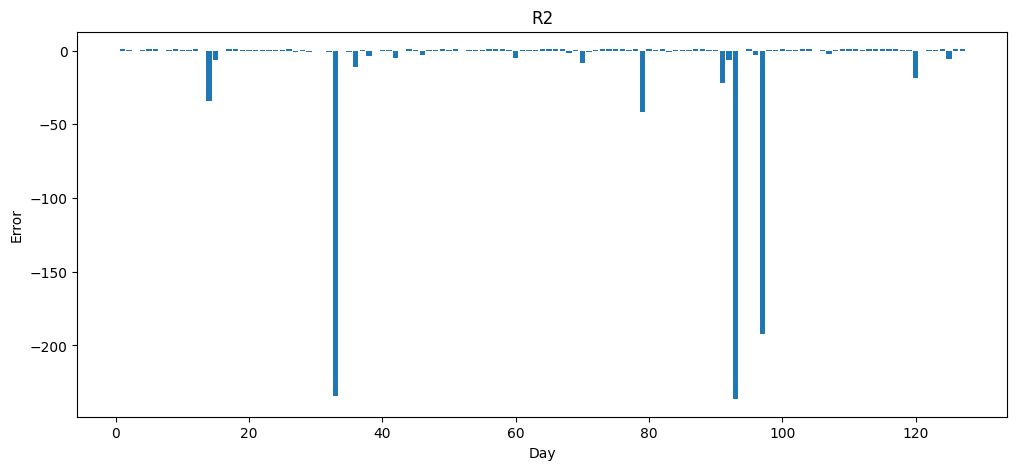

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_r2_Rear1_v2)+1), real_r2_Rear1_v2)
plt.title("R2")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

MAPE

In [ ]:
real_mape_Rear1_v2=mape_mod(yR_Rear1_test,predict_Rear1_p1_v2)
print(np.mean(real_mape_Rear1_v2))

1.108775917189191


In [ ]:
print(real_mape_Rear1_v2)

[np.float64(0.1641060817657846), np.float64(0.6604029411163599), np.float64(0.6398923660132116), np.float64(0.6677625120798687), np.float64(0.4797123847531295), np.float64(0.32909581606482347), np.float64(0.7133341121875205), np.float64(0.24597139363370912), np.float64(0.6258961423826721), np.float64(0.10592980589973218), np.float64(0.7056609114106523), np.float64(1.923150030923077), np.float64(0.527648424983565), np.float64(5.885373500567439), np.float64(2.070633875577457), np.float64(0.7839655279054977), np.float64(0.4228923099916982), np.float64(0.8566876391506226), np.float64(0.8452216862969633), np.float64(0.295809623684391), np.float64(0.25235733570000507), np.float64(0.6085120851849473), np.float64(0.4581791830419824), np.float64(0.6635106133168512), np.float64(0.37342263685371163), np.float64(0.26954502736723607), np.float64(2.378735290232329), np.float64(0.7469652542581052), np.float64(1.5557061460850738), np.float64(0.30661531318459784), np.float64(0.6968181157254404), np.flo

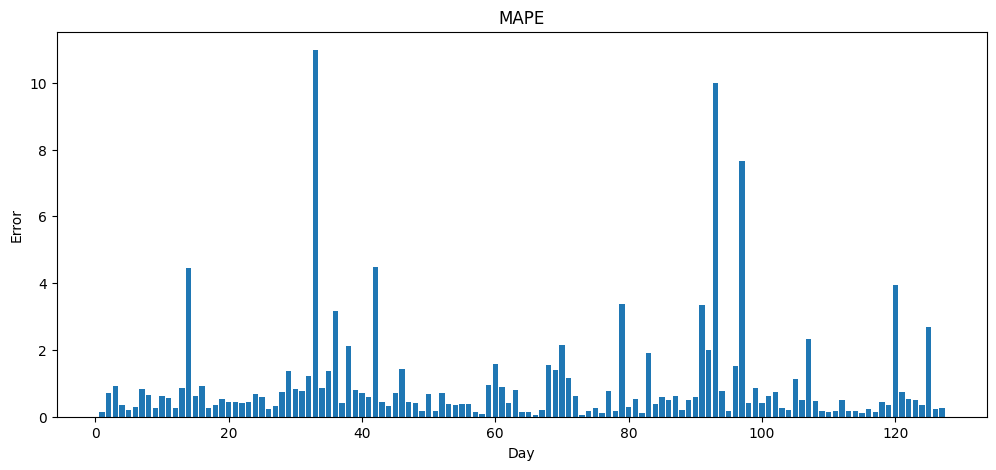

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_mape_Rear1_v2)+1), real_mape_Rear1_v2)
plt.title("MAPE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

Check the graphs to understand atypical errors

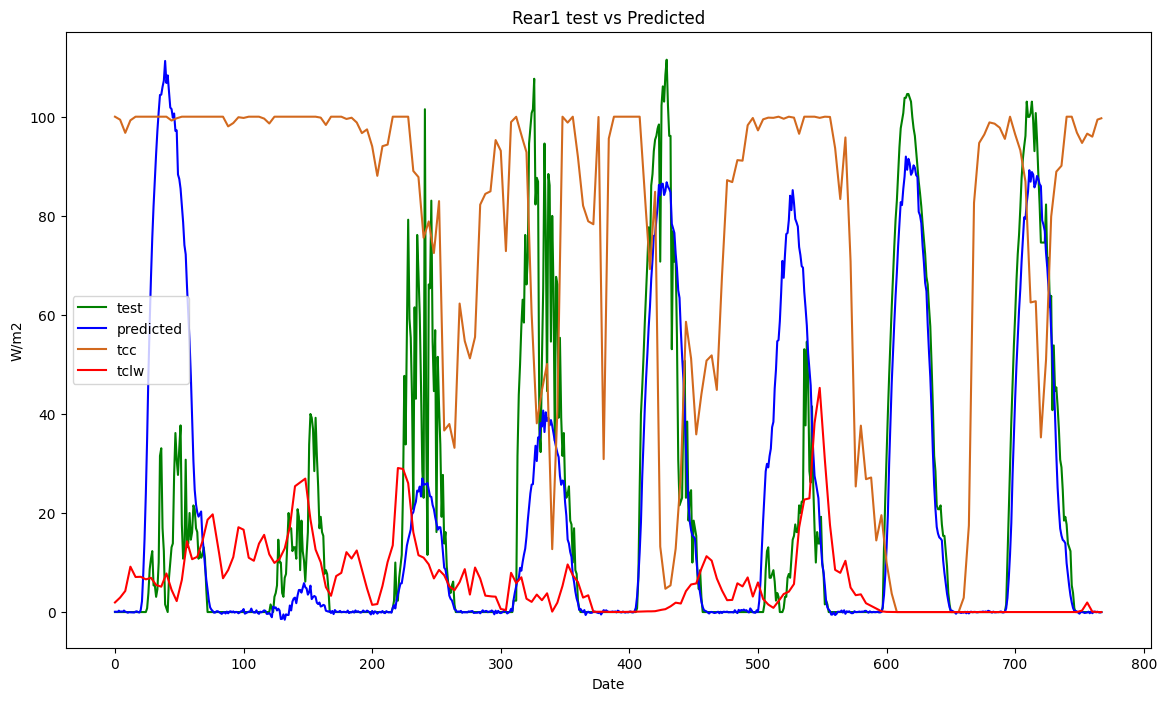

In [ ]:
plt.figure(figsize=(14,8))
st_day=120
end_day=130
dat_clouds=yR_Rear1_test.shape[0]*yR_Rear1_test.shape[1]
i_clouds=len(df3)-dat_clouds+(st_day-1)*96
f_clouds=i_clouds+(end_day-st_day)*96
plt.plot(yR_Rear1_test.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='test',color='green')
plt.plot(predict_Rear1_p1_v2.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='predicted',color='blue')
plt.plot(df3['tcc'].values[i_clouds:f_clouds],label='tcc',color='chocolate')
plt.plot(df3['tclw'].values[i_clouds:f_clouds]*50,label='tclw',color='red')
plt.title("Rear1 test vs Predicted")
plt.xlabel("Date")
plt.ylabel("W/m2")
plt.legend()
plt.show()

Model summary

In [ ]:
model1_Rear1_CNNGRU2_v2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq-input           │ (None, 384, 13)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 384, 64)   │      2,560 │ seq-input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 384, 64)   │     12,352 │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 384, 64)   │          0 │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 96)        │     46,656 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 96)        │          0 │ gru_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ surf-input          │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      6,208 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │        160 │ surf-input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 96)        │          0 │ dense_4[0][0],    │
│ (Concatenate)       │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │     12,416 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 96)        │     12,384 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 278,210 (1.06 MB)

 Trainable params: 92,736 (362.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 185,474 (724.51 KB)

CNNGRU for REAR 2

Define callbacks

In [ ]:
check_point_rear2=ModelCheckpoint(filepath="model_checkpoint/best_model_rear2.keras",monitor='mae',save_best_only=True)

Define object tuner

In [ ]:
tuner_Rear2=BayesianOptimization(create_model_tun_rear,objective='val_loss',max_trials=90,num_initial_points=18,alpha=1e-4,beta=2.6,project_name='cnngru2_tunv4_d4')

In [ ]:
tuner_Rear2.search([X1_Rear2_train,surf_Rear2_train],y1_Rear2_train,epochs=40,validation_data=([X1_Rear2_val,surf_Rear2_val],y1_Rear2_val),callbacks=[early_stop1])
tuner_Rear2.results_summary()

Trial 90 Complete [00h 00m 17s]
val_loss: 0.26192766427993774

Best val_loss So Far: 0.22261418402194977
Total elapsed time: 00h 36m 55s
Results summary
Results in ./cnngru2_tunv4_d4
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 78 summary
Hyperparameters:
kernel_size: 3
filters: 32
dropout1: 0.2
units: 32
dropout2: 0.2
units_dense: 96
dense-mid: 96
lr: 0.0005
Score: 0.22261418402194977

Trial 75 summary
Hyperparameters:
kernel_size: 3
filters: 32
dropout1: 0.1
units: 64
dropout2: 0.2
units_dense: 64
dense-mid: 96
lr: 0.0005
Score: 0.22349059581756592

Trial 03 summary
Hyperparameters:
kernel_size: 3
filters: 64
dropout1: 0.1
units: 32
dropout2: 0.1
units_dense: 64
dense-mid: 96
lr: 0.0005
Score: 0.22379887104034424

Trial 48 summary
Hyperparameters:
kernel_size: 5
filters: 32
dropout1: 0.1
units: 32
dropout2: 0.1
units_dense: 96
dense-mid: 96
lr: 0.0005
Score: 0.22718513011932373

Trial 49 summary
Hyperparameters:
kernel_size: 5
filters: 32
dropout1: 0.1
un

Define the best model

In [ ]:
model1_Rear2_CNNGRU2=tuner_Rear2.get_best_models()[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 32 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
model1_Rear2_CNNGRU2.save('/content/drive/MyDrive/Colab Notebooks/models_CNNGRU_RS/model_CNNGRU2_Rear2_n5.keras')

In [ ]:
model1_Rear2_CNNGRU2=keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/models_CNNGRU_RS/model_CNNGRU2_Rear2_n5.keras')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 30 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Prediction and evaluation

In [ ]:
pred_Rear2_p1=model1_Rear2_CNNGRU2.predict([X1_Rear2_test,surf_Rear2_test])
predict_Rear2_p1=(scaler_Rear2.inverse_transform(pred_Rear2_p1.reshape(-1,1))).reshape(pred_Rear2_p1.shape[0],pred_Rear2_p1.shape[1])

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step


MAE

In [ ]:
real_loss_Rear2=list_mae(yR_Rear2_test,predict_Rear2_p1)
print(np.mean(real_loss_Rear2))

7.262408068221914


In [ ]:
print(real_loss_Rear2)

[3.8651410711758385, 9.311866320274282, 27.038350824621357, 13.062886112507536, 15.564122975952797, 8.324146691429563, 12.67274303037361, 11.594423602921111, 2.6006517032339223, 8.461496204282332, 8.73690978816692, 2.011957503515236, 11.433573364840754, 2.5862592145345555, 1.4116337096573754, 39.7073406132209, 6.868489037058663, 17.674905659884466, 14.281667790720656, 8.109644078698883, 6.7546533535382975, 2.79153132744608, 9.113529028456771, 3.8601833600317046, 7.155298973997053, 3.8387226184806296, 1.4598619737898793, 10.25891510573325, 9.8770853552041, 6.352282219385297, 9.578146989745557, 6.696843372280381, 1.3571864652305312, 8.853934482140644, 9.921744942617872, 2.585147553798788, 8.768220716107017, 10.954531206502898, 4.105429065864079, 2.5997387041954045, 11.342591343247094, 4.948475189453033, 1.8302774187219368, 4.854787503845918, 7.2869953984809825, 8.519562803398559, 7.927273115475806, 11.306212320674655, 5.266665113255155, 14.225962485536689, 2.3912118904291058, 6.914799472

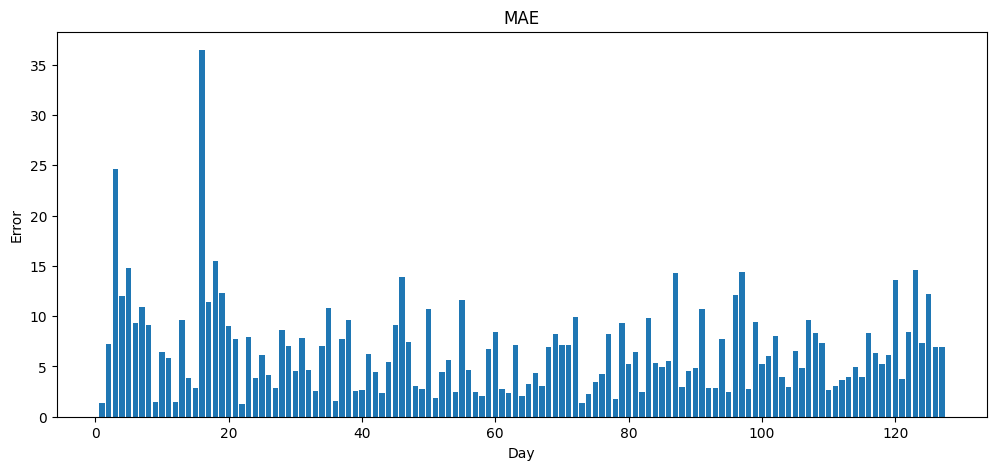

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_loss_Rear2)+1), real_loss_Rear2)
plt.title("MAE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

R2

In [ ]:
real_r2_Rear2=list_r2(yR_Rear2_test,predict_Rear2_p1)
print(np.mean(real_r2_Rear2))

-6.720100235827072


In [ ]:
print(real_r2_Rear2)

[0.7257479609001621, -0.10347366442164696, -0.2721493867629352, 0.27662080683202805, 0.2676494215365074, 0.6113119483876901, -0.14467394155558488, 0.03657353061992419, 0.3927638534177137, 0.12227049732336437, -0.04605038936595629, 0.5045881342062208, -0.19177192822216393, -12.228334555322679, -24.58871852085125, -0.2987960702680539, 0.7739342884922406, -0.20437154808852243, -0.16179478876692355, 0.57377721777952, 0.6417729595802075, 0.33196404578359706, 0.2205084546365249, 0.6925798499585831, 0.3041418358437292, 0.8133713838151757, -100.08278561083051, -0.1365681808323418, -4.570090390284159, -0.010922385793049827, -0.11513480453935676, -3.6184281476484976, -6.0497489752439835, -0.14973194388216915, -20.172534423860185, 0.2504004204822057, 0.1914483695632706, -18.43851141760052, 0.08272234902495668, -0.002458606156460208, 0.0599932751979112, -2.4879034301788017, -0.6455687854438728, 0.7985819808510608, -0.08833883214961413, -4.310947473854064, -0.8574351873627322, 0.02104554177776985, 

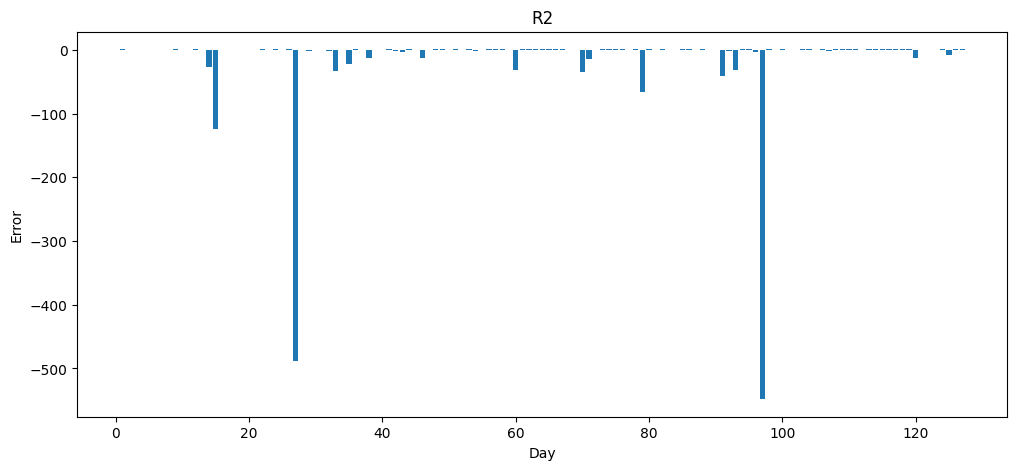

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_r2_Rear2)+1),real_r2_Rear2)
plt.title("R2")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

MAPE

In [ ]:
real_mape_Rear2=mape_mod(yR_Rear2_test,predict_Rear2_p1)
print(np.mean(real_mape_Rear2))

nan


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
print(real_mape_Rear2)

[np.float64(0.43061580300588664), np.float64(0.8170206158031426), np.float64(0.9411274185945733), np.float64(0.6367659791135495), np.float64(0.7387966959994209), np.float64(0.48137222323238343), np.float64(0.8865195291828862), np.float64(0.8036394428505395), np.float64(0.5138374482976678), np.float64(0.7731232900329802), np.float64(0.8288659947797252), np.float64(0.4142194372707591), np.float64(0.8678883408583777), np.float64(0.35171497078446684), np.float64(nan), np.float64(0.9630062288027698), np.float64(0.3505321693207925), np.float64(0.9115285973451002), np.float64(0.8952670950304448), np.float64(0.5469142204928765), np.float64(0.49378087094956763), np.float64(0.5853118385640054), np.float64(0.7480206522638503), np.float64(0.7801459555945522), np.float64(0.6710141493644838), np.float64(0.3414501123146423), np.float64(nan), np.float64(0.8534150069749994), np.float64(2.441919501735702), np.float64(0.78871363430438), np.float64(0.8524871527652127), np.float64(2.0493465306432594), np.f

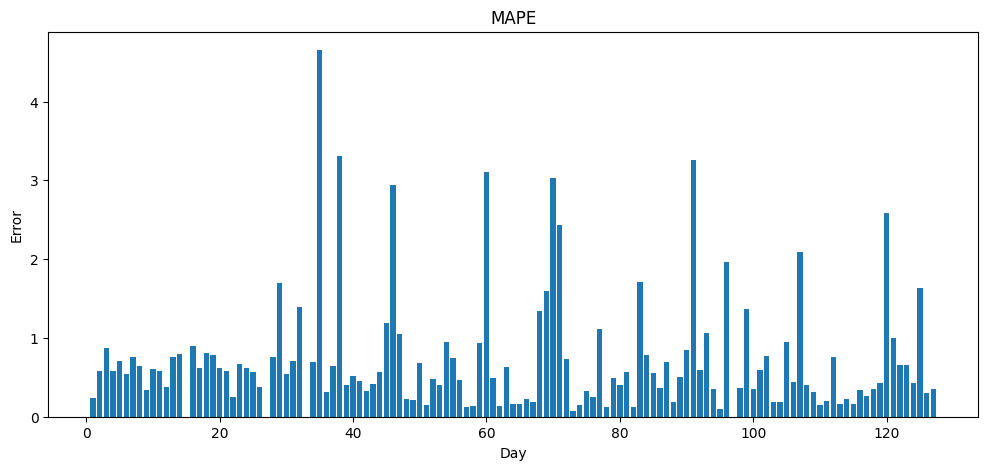

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_mape_Rear2)+1), real_mape_Rear2)
plt.title("MAPE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

Check the graphs to understand atypical errors

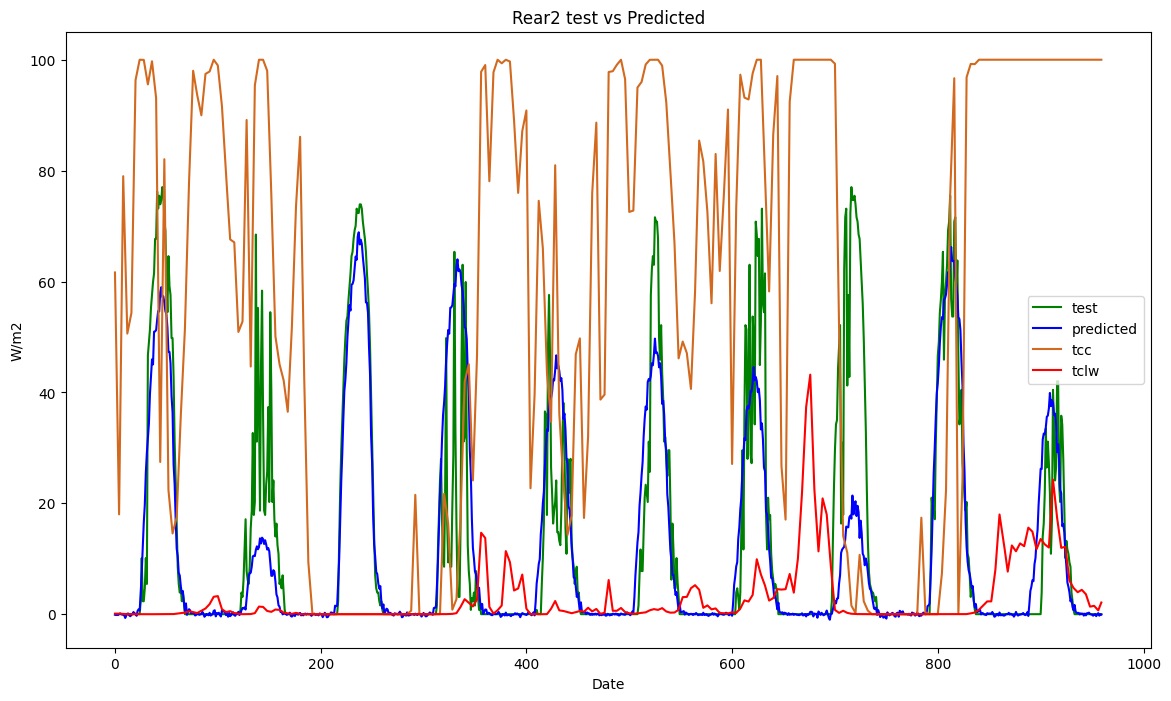

In [ ]:
plt.figure(figsize=(14,8))
st_day=80
end_day=90
dat_clouds=yR_Rear2_test.shape[0]*yR_Rear2_test.shape[1]
i_clouds=len(df3)-dat_clouds+(st_day-1)*96
f_clouds=i_clouds+(end_day-st_day)*96
plt.plot(yR_Rear2_test.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='test',color='green')
plt.plot(predict_Rear2_p1.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='predicted',color='blue')
plt.plot(df3['tcc'].values[i_clouds:f_clouds],label='tcc',color='chocolate')
plt.plot(df3['tclw'].values[i_clouds:f_clouds]*50,label='tclw',color='red')
plt.title("Rear2 test vs Predicted")
plt.xlabel("Date")
plt.ylabel("W/m2")
plt.legend()
plt.show()

In [ ]:
model1_Rear2_CNNGRU2.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq-input           │ (None, 384, 14)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 384, 32)   │      1,376 │ seq-input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 384, 32)   │      3,104 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 384, 32)   │          0 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 32)        │      6,336 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ surf-input          │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 96)        │      3,168 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        160 │ surf-input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128)       │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 96)        │     12,384 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 96)        │      9,312 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 35,840 (140.00 KB)

 Trainable params: 35,840 (140.00 KB)

 Non-trainable params: 0 (0.00 B)

Retraining in case you need it

In [ ]:
X1_Rear2_train=np.concatenate((X1_Rear2_train,X1_Rear2_val),axis=0)
y1_Rear2_train=np.concatenate((y1_Rear2_train,y1_Rear2_val),axis=0)
surf_Rear2_train=np.concatenate((surf_Rear2_train,surf_Rear2_val),axis=0)

print(X1_Rear2_train.shape)
print(y1_Rear2_train.shape)
print(surf_Rear2_train.shape)

(1133, 384, 14)
(1133, 96)
(1133, 4)


In [ ]:
model1_Rear2_CNNGRU2_v2=create_model_rear([X1_Rear2_train,surf_Rear2_train],y1_Rear2_train,70,0.0005,check_point_rear2)

Epoch 1/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.8012 - mae: 0.8012 - mape: 20547710.0000 - mse: 2.7527
Epoch 2/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.6622 - mae: 0.6622 - mape: 26076690.0000 - mse: 1.9968
Epoch 3/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.4796 - mae: 0.4796 - mape: 29428346.0000 - mse: 0.9610
Epoch 4/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.4313 - mae: 0.4313 - mape: 23934072.0000 - mse: 0.7601
Epoch 5/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.4198 - mae: 0.4198 - mape: 21714072.0000 - mse: 0.7394
Epoch 6/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.4139 - mae: 0.4139 - mape: 19747178.0000 - mse: 0.7385
Epoch 7/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.4080 - mae: 0.4080 - mape: 18213532.0000 - mse: 0.7351
Epoch 8/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.4043 - mae: 0.4043 - mape: 18191964.0000 - mse: 0.7313
Epoch 9/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.3984 - mae:

In [ ]:
model1_Rear2_CNNGRU2_v2=load_model("model_checkpoint/best_model_rear2.keras")

Save the model

In [ ]:
model1_Rear2_CNNGRU2_v2.save('/content/drive/MyDrive/Colab Notebooks/models_CNNGRU_RS/model_CNNGRU2_Rear2_n5_v2.keras')

In [ ]:
model1_Rear2_CNNGRU2_v2=keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/models_CNNGRU_RS/model_CNNGRU2_Rear2_n5_v2.keras')

Prediction and evaluation

In [ ]:
pred_Rear2_p1_v2=model1_Rear2_CNNGRU2_v2.predict([X1_Rear2_test,surf_Rear2_test])
predict_Rear2_p1_v2=(scaler_Rear2.inverse_transform(pred_Rear2_p1_v2.reshape(-1,1))).reshape(pred_Rear2_p1_v2.shape[0],pred_Rear2_p1_v2.shape[1])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


MAE

In [ ]:
real_loss_Rear2_v2=list_mae(yR_Rear2_test,predict_Rear2_p1_v2)
print(np.mean(real_loss_Rear2_v2))

7.555545491935288


In [ ]:
print(real_loss_Rear2_v2)

[1.8583295148747307, 8.494650855103247, 12.460889710128749, 11.478164933195577, 14.033900439057405, 8.872645212089994, 11.798895146910008, 4.867602101726615, 1.8793189430572361, 2.9863198652970495, 6.566767533028738, 2.588572613641631, 10.340220110931568, 11.083279912833062, 1.4927975016338142, 38.970775650769944, 6.612654221336843, 11.437330522374962, 8.52016790061719, 2.431974550560025, 1.5898363833415914, 1.65262030232626, 3.5752067945438153, 5.289282012639614, 2.4245499708856353, 3.019330301688863, 1.9146148495271824, 9.24866549675517, 8.415184098022864, 5.186066674087736, 8.447530173923168, 10.895883912590833, 9.651766924596423, 7.749540578336308, 12.732186682695314, 1.562721159433137, 3.908633404992044, 13.26160844184023, 3.205425012874142, 2.3305121715266455, 1.5045591333407284, 7.002242026304054, 1.5584543950979137, 6.757719991455474, 9.355171535853346, 10.495928693775202, 6.707064029422274, 5.215836550983849, 6.167155821140116, 13.542469346587751, 4.48160296137181, 6.313757189

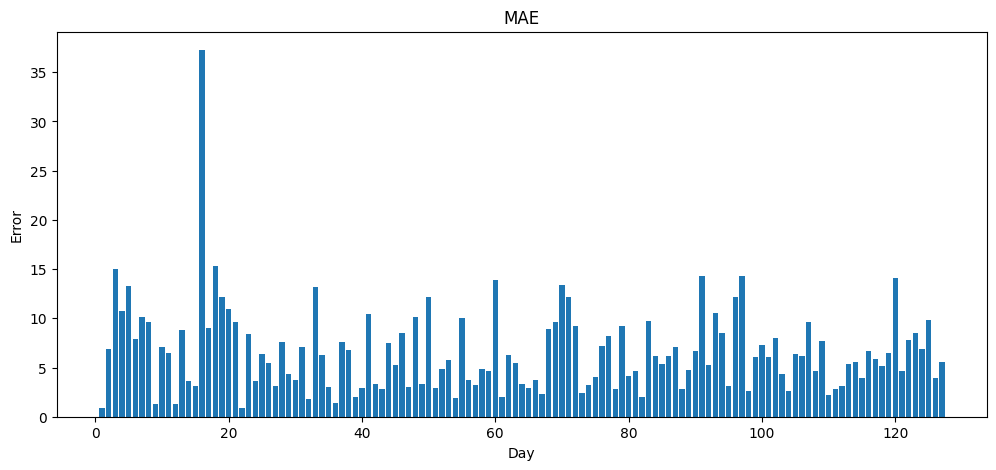

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_loss_Rear2_v2)+1), real_loss_Rear2_v2)
plt.title("MAE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

R2

In [ ]:
real_r2_Rear2_v2=list_r2(yR_Rear2_test,predict_Rear2_p1_v2)
print(np.mean(real_r2_Rear2_v2))

-21.02893962385649


In [ ]:
print(real_r2_Rear2_v2)

[0.9372577276525765, 0.0263796568609026, 0.7391244148766718, 0.37441617524381254, 0.3928477902270756, 0.5447220567454477, -0.04174884477184038, 0.8353199166391168, 0.5856825356377859, 0.8936897789627487, 0.39652226397314205, 0.04097269856632091, -0.06521775586426615, -251.09059521539044, -43.60869704695321, -0.2694947382283628, 0.7779068371154094, 0.4756329497142646, 0.5864644729458361, 0.9534185092774492, 0.9781873985439529, 0.7441953648100493, 0.8888905320530843, 0.2160305188291981, 0.8827827061179914, 0.8819354086836906, -293.7904144512615, 0.01937847303504625, -3.193232904527802, 0.22488350336534113, 0.07625208274494566, -10.63338005427949, -588.9924474873926, 0.04836702733163123, -33.1539731343876, 0.5530738501173722, 0.828778533858886, -27.65318768930247, 0.2504223803104435, 0.25437498105848133, 0.9815631220004687, -5.393874347988249, -0.944540970408142, 0.4431108683293389, -1.0806010009170968, -7.792827291019403, -0.37131996100247466, 0.7672890562783563, 0.7318149269424636, -0.0

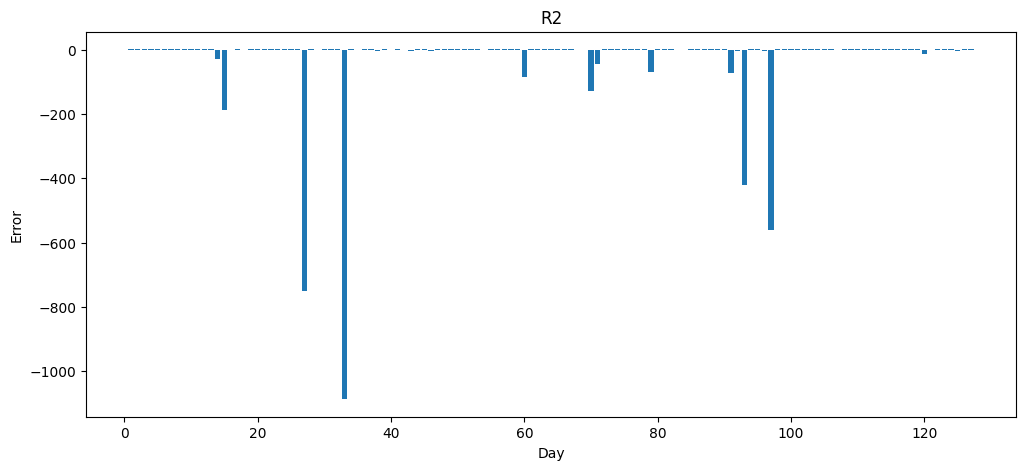

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_r2_Rear2_v2)+1), real_r2_Rear2_v2)
plt.title("R2")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

MAPE

In [ ]:
real_mape_Rear2_v2=mape_mod(yR_Rear2_test,predict_Rear2_p1_v2)
print(np.mean(real_mape_Rear2_v2))

nan


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
print(real_mape_Rear2_v2)

[np.float64(0.29563772735537097), np.float64(0.7894043128581361), np.float64(0.4577615199067722), np.float64(0.5520892343740561), np.float64(0.6764176588520073), np.float64(0.5467410322638948), np.float64(0.8523619666762479), np.float64(0.3577577300234189), np.float64(0.6724176318917557), np.float64(0.30240878487837175), np.float64(0.6685551243795304), np.float64(0.8553788892891439), np.float64(0.8038842753258387), np.float64(2.268052029003749), np.float64(nan), np.float64(0.9548451498615602), np.float64(0.34800791582047313), np.float64(0.5858202651013116), np.float64(0.5585455594887018), np.float64(0.2512923784973944), np.float64(0.1464522403806961), np.float64(0.35677082604054783), np.float64(0.3323387260513634), np.float64(1.205099492225773), np.float64(0.33799595487073825), np.float64(0.315207022893247), np.float64(nan), np.float64(0.8397360548593401), np.float64(2.0905227120226577), np.float64(0.6786260697900669), np.float64(0.7887779624451428), np.float64(3.3073749343261443), np.

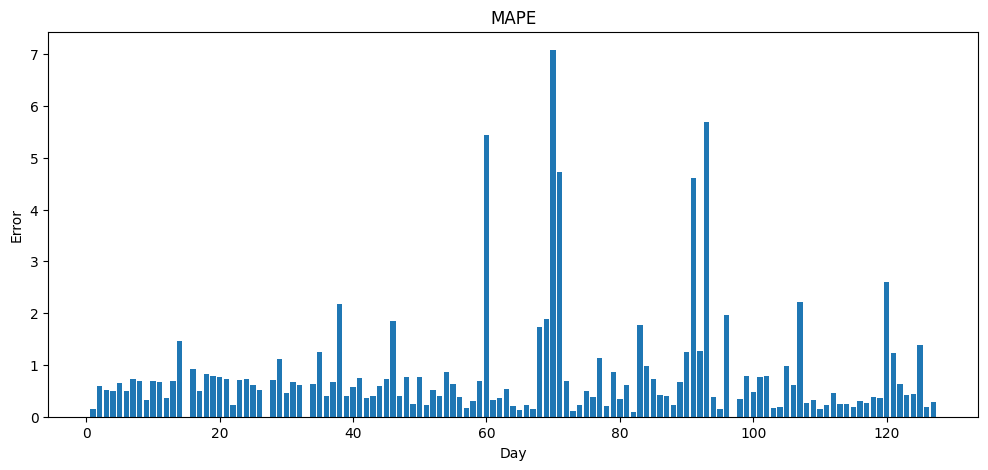

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_mape_Rear2_v2)+1), real_mape_Rear2_v2)
plt.title("MAPE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

Check the graphs to understand atypical errors

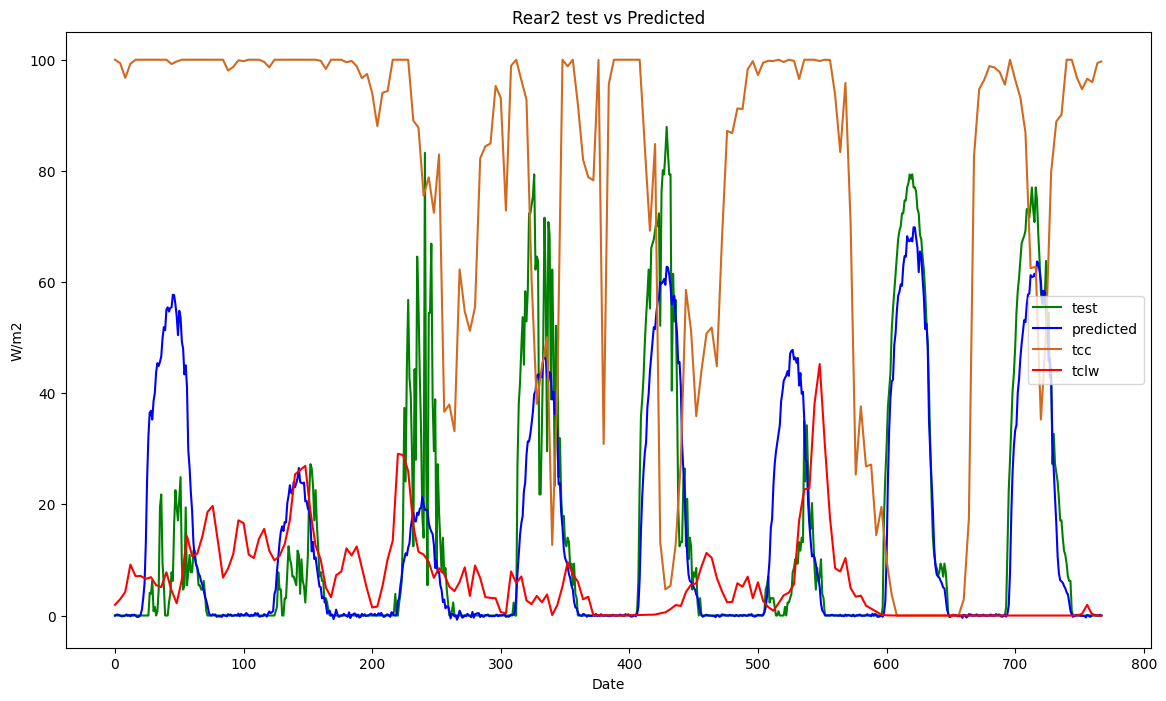

In [ ]:
plt.figure(figsize=(14,8))
st_day=120
end_day=130
dat_clouds=yR_Rear2_test.shape[0]*yR_Rear2_test.shape[1]
i_clouds=len(df3)-dat_clouds+(st_day-1)*96
f_clouds=i_clouds+(end_day-st_day)*96
plt.plot(yR_Rear2_test.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='test',color='green')
plt.plot(predict_Rear2_p1_v2.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='predicted',color='blue')
plt.plot(df3['tcc'].values[i_clouds:f_clouds],label='tcc',color='chocolate')
plt.plot(df3['tclw'].values[i_clouds:f_clouds]*50,label='tclw',color='red')
plt.title("Rear2 test vs Predicted")
plt.xlabel("Date")
plt.ylabel("W/m2")
plt.legend()
plt.show()

Model summary

In [ ]:
model1_Rear2_CNNGRU2_v2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq-input           │ (None, 384, 14)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 384, 32)   │      1,376 │ seq-input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 384, 32)   │      3,104 │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 384, 32)   │          0 │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 32)        │      6,336 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ gru_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ surf-input          │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 96)        │      3,168 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │        160 │ surf-input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128)       │          0 │ dense_4[0][0],    │
│ (Concatenate)       │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 96)        │     12,384 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 96)        │      9,312 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 107,522 (420.01 KB)

 Trainable params: 35,840 (140.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 71,682 (280.01 KB)

CNNGRU for REAR 3

Define callbaks

In [ ]:
check_point_rear3=ModelCheckpoint(filepath="model_checkpoint/best_model_rear3.keras",monitor='mae',save_best_only=True)

Define object tuner

In [ ]:
tuner_Rear3=BayesianOptimization(create_model_tun_rear,objective='val_loss',max_trials=90,num_initial_points=18,alpha=1e-4,beta=2.6,project_name='cnngru2_tun_d5')

In [ ]:
tuner_Rear3.search([X1_Rear3_train,surf_Rear3_train],y1_Rear3_train,epochs=40,validation_data=([X1_Rear3_val,surf_Rear3_val],y1_Rear3_val),callbacks=[early_stop1])
tuner_Rear3.results_summary()

Trial 90 Complete [00h 00m 38s]
val_loss: 0.2099049985408783

Best val_loss So Far: 0.20347678661346436
Total elapsed time: 00h 50m 19s
Results summary
Results in ./cnngru2_tun_d5
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 78 summary
Hyperparameters:
kernel_size: 3
filters: 32
dropout1: 0.1
units: 32
dropout2: 0.1
units_dense: 64
dense-mid: 96
lr: 0.0005
Score: 0.20347678661346436

Trial 65 summary
Hyperparameters:
kernel_size: 3
filters: 32
dropout1: 0.1
units: 32
dropout2: 0.1
units_dense: 64
dense-mid: 96
lr: 0.0005
Score: 0.20368623733520508

Trial 50 summary
Hyperparameters:
kernel_size: 5
filters: 32
dropout1: 0.2
units: 32
dropout2: 0.2
units_dense: 64
dense-mid: 96
lr: 0.0005
Score: 0.20370566844940186

Trial 74 summary
Hyperparameters:
kernel_size: 3
filters: 32
dropout1: 0.1
units: 32
dropout2: 0.1
units_dense: 64
dense-mid: 96
lr: 0.0005
Score: 0.20544853806495667

Trial 39 summary
Hyperparameters:
kernel_size: 3
filters: 32
dropout1: 0.2
units

Define the best model

In [ ]:
model1_Rear3_CNNGRU2=tuner_Rear3.get_best_models()[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 32 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Save and Load the model

In [ ]:
model1_Rear3_CNNGRU2.save('/content/drive/MyDrive/Colab Notebooks/models_CNNGRU_RS/model_CNNGRU2_Rear3_n5.keras')

In [ ]:
model1_Rear3_CNNGRU2=keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/models_CNNGRU_RS/model_CNNGRU2_Rear3_n5.keras')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 32 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Prediction and evaluation

In [ ]:
pred_Rear3_p1=model1_Rear3_CNNGRU2.predict([X1_Rear3_test,surf_Rear3_test])
predict_Rear3_p1=(scaler_Rear3.inverse_transform(pred_Rear3_p1.reshape(-1,1))).reshape(pred_Rear3_p1.shape[0],pred_Rear3_p1.shape[1])

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step


MAE

In [ ]:
real_loss_Rear3=list_mae(yR_Rear3_test,predict_Rear3_p1)
print(np.mean(real_loss_Rear3))

8.325781467689833


In [ ]:
print(real_loss_Rear3)

[1.5859872445768282, 10.122873134487103, 25.60882336540065, 8.089147406360318, 8.013573172545536, 4.2706236362185095, 12.595997970002491, 6.851485749568422, 1.8862254942731198, 7.0557149054296175, 7.428012097191325, 3.8014241453190727, 13.290649948051785, 8.649078604478447, 1.8277160021052499, 41.97291221262382, 4.909908921283627, 16.477119060046935, 11.15325804908165, 4.979017230974097, 4.068676044356512, 2.9112481355497586, 6.792599348813962, 4.763716850166181, 6.973530111340859, 3.06189823707293, 1.9989578527080247, 13.457690809574558, 8.47169058177835, 7.219544976147058, 11.94458505251618, 7.775553292659173, 1.8054687800940794, 10.681116738140394, 10.640687229029055, 3.2668163533112655, 8.282347891831234, 11.524789012188942, 5.250844412715489, 2.8121081729517114, 10.850965468148006, 7.032338216547032, 1.8867673152316187, 8.060976645468992, 4.887126161227166, 4.810362299987189, 9.034380963488553, 9.194158364056136, 5.19899774282788, 13.297932141024345, 6.157320612012455, 5.063217649

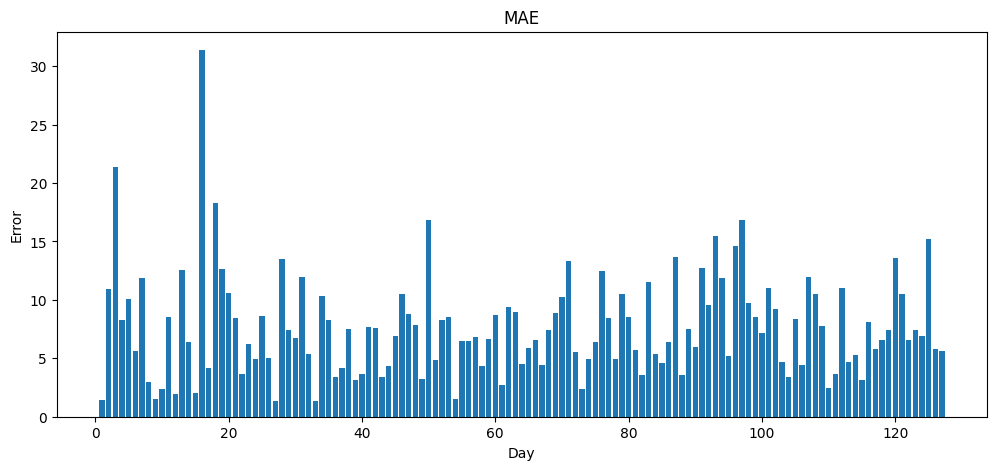

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_loss_Rear3)+1), real_loss_Rear3)
plt.title("MAE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

R2

In [ ]:
real_r2_Rear3=list_r2(yR_Rear3_test,predict_Rear3_p1)
print(np.mean(real_r2_Rear3))

-2.1860229210477233


In [ ]:
print(real_r2_Rear3)

[0.9758731049235362, 0.1412764711367771, -0.05332665987708496, 0.6496616278435101, 0.7963654527003732, 0.9071202707230743, -0.06969208483189848, 0.7544225417477077, 0.8541618418421204, 0.6625066442522727, 0.6022898466680627, 0.051122448569276835, -0.12799156153944113, -43.69531071327351, -8.24983041136623, -0.22739335068126842, 0.8871268720745287, 0.21268365603811668, 0.49187603576286043, 0.9015855891220043, 0.9232077633484845, 0.656858490177971, 0.7709051011417222, 0.7014522705559506, 0.6249558560694471, 0.933171681644767, -24.62423051662805, -0.100478238204184, -1.5959127214927276, 0.11160978684057721, -0.0370488805156286, -2.10504833963773, -2.5986023255503388, -0.016434331449774353, -11.671199862022442, 0.36795181764166673, 0.6116404321749171, -10.487725319955015, 0.018945630412314785, 0.25104386492046726, 0.5440573621090554, -2.9658327904245523, -0.027956607024627766, 0.7115490826039366, 0.7484791194631253, 0.17855835195055192, -0.5231162840506063, 0.625353449173511, 0.89861254936

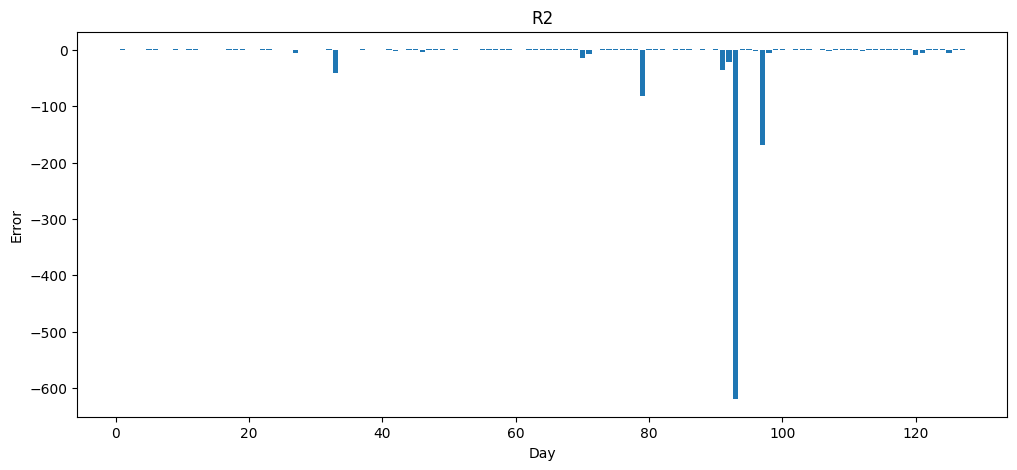

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_r2_Rear3)+1),real_r2_Rear3)
plt.title("R2")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

MAPE

In [ ]:
real_mape_Rear3=mape_mod(yR_Rear3_test,predict_Rear3_p1)
print(np.mean(real_mape_Rear3))

nan


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
print(real_mape_Rear3)

[np.float64(0.1414777733192695), np.float64(0.7224436211263716), np.float64(0.8592072838772972), np.float64(0.4043355188332714), np.float64(0.39685919308336765), np.float64(0.2873239006878377), np.float64(0.8193702775583146), np.float64(0.443125454355097), np.float64(0.3369418078578355), np.float64(0.5054224034861069), np.float64(0.5501371978085552), np.float64(0.8212635600961588), np.float64(0.8426939713913691), np.float64(2.3326170505977912), np.float64(0.09347999015624092), np.float64(0.9247961678972076), np.float64(0.2316115612100645), np.float64(0.7499011501758311), np.float64(0.6142016369388419), np.float64(0.3045831898243805), np.float64(0.2652215181181439), np.float64(0.4755989020905716), np.float64(0.44175263499542267), np.float64(0.6992251004406188), np.float64(0.5379217047284185), np.float64(0.22106632611404642), np.float64(nan), np.float64(0.8712997729857357), np.float64(1.6231357801101962), np.float64(0.743505784276377), np.float64(0.8128706706358145), np.float64(1.6561123

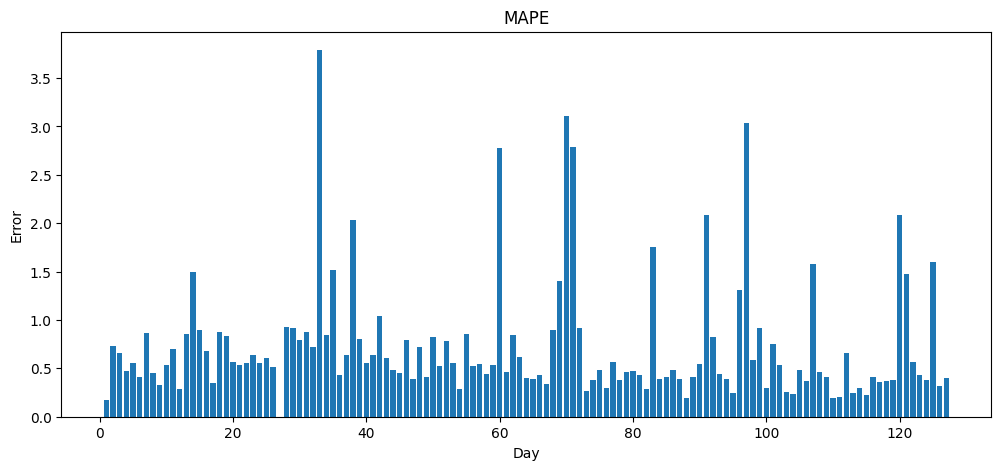

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_mape_Rear3)+1), real_mape_Rear3)
plt.title("MAPE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

Check the graphs to understand atypical errors

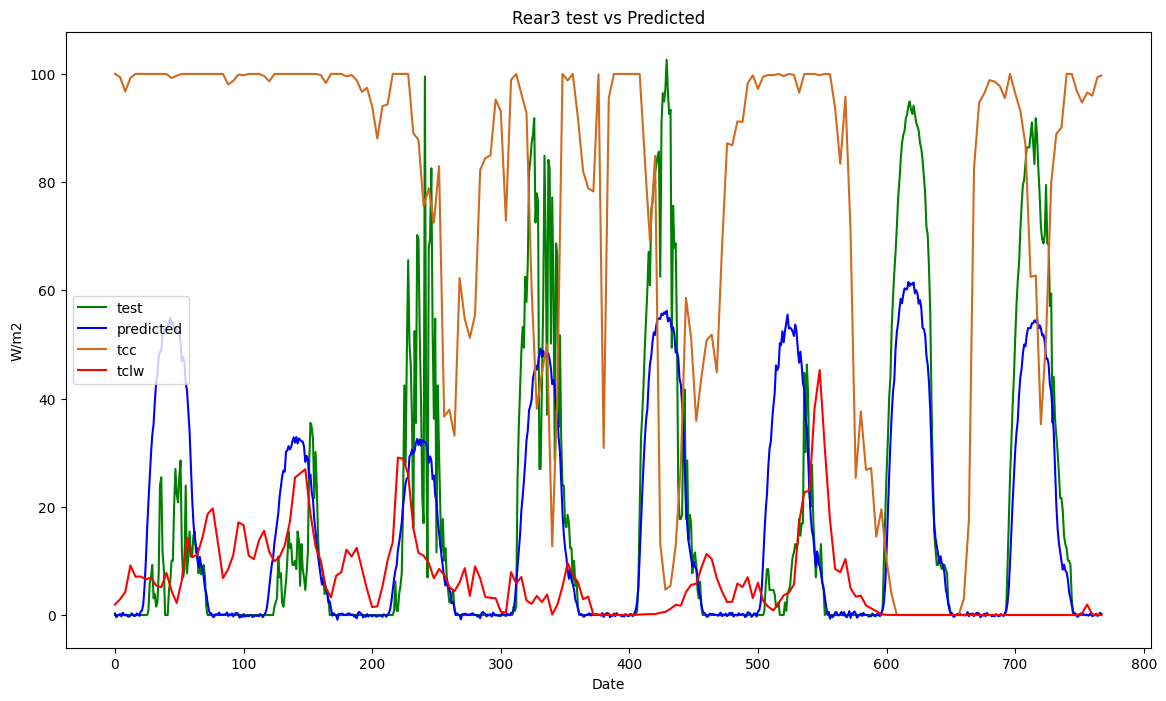

In [ ]:
plt.figure(figsize=(14,8))
st_day=120
end_day=130
dat_clouds=yR_Rear3_test.shape[0]*yR_Rear3_test.shape[1]
i_clouds=len(df3)-dat_clouds+(st_day-1)*96
f_clouds=i_clouds+(end_day-st_day)*96
plt.plot(yR_Rear3_test.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='test',color='green')
plt.plot(predict_Rear3_p1.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='predicted',color='blue')
plt.plot(df3['tcc'].values[i_clouds:f_clouds],label='tcc',color='chocolate')
plt.plot(df3['tclw'].values[i_clouds:f_clouds]*50,label='tclw',color='red')
plt.title("Rear3 test vs Predicted")
plt.xlabel("Date")
plt.ylabel("W/m2")
plt.legend()
plt.show()

In [ ]:
model1_Rear3_CNNGRU2.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq-input           │ (None, 384, 14)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 384, 32)   │      1,376 │ seq-input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 384, 32)   │      3,104 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 384, 32)   │          0 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 32)        │      6,336 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ surf-input          │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      2,112 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        160 │ surf-input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 96)        │      9,312 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 96)        │      9,312 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 95,138 (371.64 KB)

 Trainable params: 31,712 (123.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 63,426 (247.76 KB)

Retraining in case you need it

In [ ]:
X1_Rear3_train=np.concatenate((X1_Rear3_train,X1_Rear3_val),axis=0)
y1_Rear3_train=np.concatenate((y1_Rear3_train,y1_Rear3_val),axis=0)
surf_Rear3_train=np.concatenate((surf_Rear3_train,surf_Rear3_val),axis=0)

print(X1_Rear3_train.shape)
print(y1_Rear3_train.shape)
print(surf_Rear3_train.shape)

(1133, 384, 14)
(1133, 96)
(1133, 4)


In [ ]:
model1_Rear3_CNNGRU2_v2=create_model_rear([X1_Rear3_train,surf_Rear3_train],y1_Rear3_train,70,0.0005,check_point_rear3)

Epoch 1/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.7913 - mae: 0.7913 - mape: 12151053.0000 - mse: 2.5791
Epoch 2/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.6614 - mae: 0.6614 - mape: 12664636.0000 - mse: 1.9573
Epoch 3/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.4948 - mae: 0.4948 - mape: 16592912.0000 - mse: 0.9688
Epoch 4/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.4262 - mae: 0.4262 - mape: 14428423.0000 - mse: 0.7415
Epoch 5/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.3986 - mae: 0.3986 - mape: 12666297.0000 - mse: 0.6373
Epoch 6/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.3886 - mae: 0.3886 - mape: 11455548.0000 - mse: 0.6359
Epoch 7/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.3790 - mae: 0.3790 - mape: 10449980.0000 - mse: 0.6208
Epoch 8/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.3717 - mae: 0.3717 - mape: 9787578.0000 - mse: 0.6140
Epoch 9/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.3638 - mae: 

In [ ]:
model1_Rear3_CNNGRU2_v2=load_model("model_checkpoint/best_model_rear3.keras")

Save the model

In [ ]:
model1_Rear3_CNNGRU2_v2.save('/content/drive/MyDrive/Colab Notebooks/models_CNNGRU_RS/model_CNNGRU2_Rear3_n5_v2.keras')

In [ ]:
model1_Rear3_CNNGRU2_v2=keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/models_CNNGRU_RS/model_CNNGRU2_Rear3_n5_v2.keras')

Prediction and evaluation

In [ ]:
pred_Rear3_p1_v2=model1_Rear3_CNNGRU2_v2.predict([X1_Rear3_test,surf_Rear3_test])
predict_Rear3_p1_v2=(scaler_Rear3.inverse_transform(pred_Rear3_p1_v2.reshape(-1,1))).reshape(pred_Rear3_p1_v2.shape[0],pred_Rear3_p1_v2.shape[1])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


MAE

In [ ]:
real_loss_Rear3_v2=list_mae(yR_Rear3_test,predict_Rear3_p1_v2)
print(np.mean(real_loss_Rear3_v2))

8.457507938960864


In [ ]:
print(real_loss_Rear3_v2)

[5.754342246948024, 7.400659904927383, 12.108022076266687, 8.071702152960027, 7.689215451906811, 5.699940124875113, 10.216896799114853, 10.899384405242918, 1.623049778234862, 9.066224629741543, 2.360323379720944, 2.504270364517095, 11.335349652731518, 2.9344713458281393, 2.743366651464258, 36.568257905512446, 6.478332113224828, 7.310914504302716, 3.9383199909017974, 11.03562097437409, 9.208735246567231, 1.5069046473451853, 6.143842978914179, 4.940145411723278, 8.11514653807521, 6.602590783766877, 3.342463027672741, 12.540433429496517, 10.184281056690223, 5.027829384066917, 10.12431896377896, 5.753750840653649, 7.80366827480497, 9.271784792718911, 11.5333052212952, 4.372739808025084, 7.578206109685534, 10.26223570814014, 5.205961597125955, 4.374612721168469, 3.005930164247051, 11.354240908577196, 5.10959260455632, 7.824137955135394, 17.69927875065227, 25.295077965666493, 15.173959212682249, 10.911857176003645, 7.9972683714710575, 3.510983348522968, 2.8092105226366963, 4.89631372702553, 

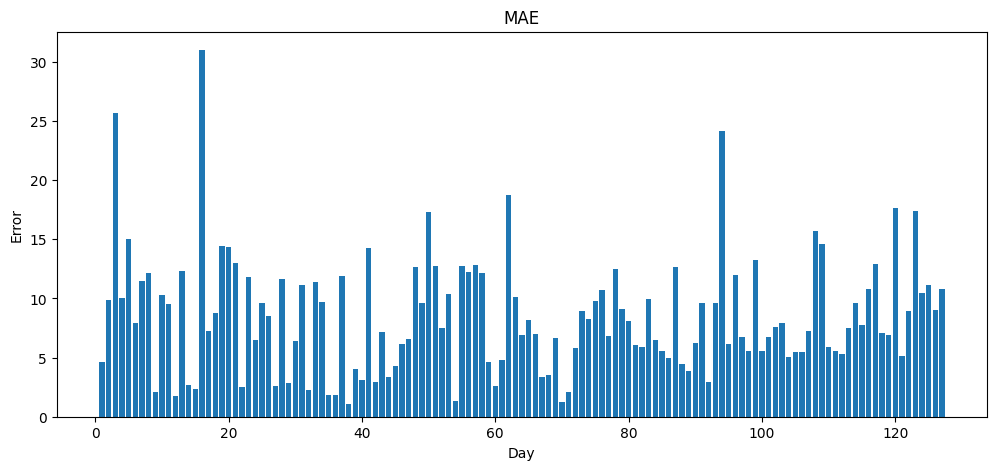

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_loss_Rear3_v2)+1), real_loss_Rear3_v2)
plt.title("MAE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

R2

In [ ]:
real_r2_Rear3_v2=list_r2(yR_Rear3_test,predict_Rear3_p1_v2)
print(np.mean(real_r2_Rear3_v2))

-8.303275766856691


In [ ]:
print(real_r2_Rear3_v2)

[0.6017442741348233, 0.4229627835604375, 0.7706818774673252, 0.6327202198901787, 0.8061828450417761, 0.7908364783759498, 0.2067217364946906, 0.301133382343004, 0.8305923326691275, 0.390240663735412, 0.9557835480101419, 0.44266530051438124, 0.14045437780618408, -4.901187600223718, -28.095887708348883, 0.050320136356689416, 0.8134033785408394, 0.8488181557018711, 0.9251463306783405, 0.4505545294215966, 0.5617201668380902, 0.8507747672031439, 0.7964330769905833, 0.7192289957050553, 0.45838863367076466, 0.6664432575464063, -94.16312340388886, 0.01755554580632146, -2.8767373076633973, 0.475039219016014, 0.2045523513933175, -0.8735871300347398, -101.50954867532295, 0.20760848045022584, -14.39207262101053, -0.16616787551470136, 0.6588089915924356, -8.396039385548677, 0.027904261324476654, -0.006263529025027026, 0.9597319837518017, -8.77328554375579, -8.829693282919852, 0.6100979461656897, -2.384330905259392, -24.442824681576127, -3.400548794728601, 0.4252409322536078, 0.716029241702911, 0.949

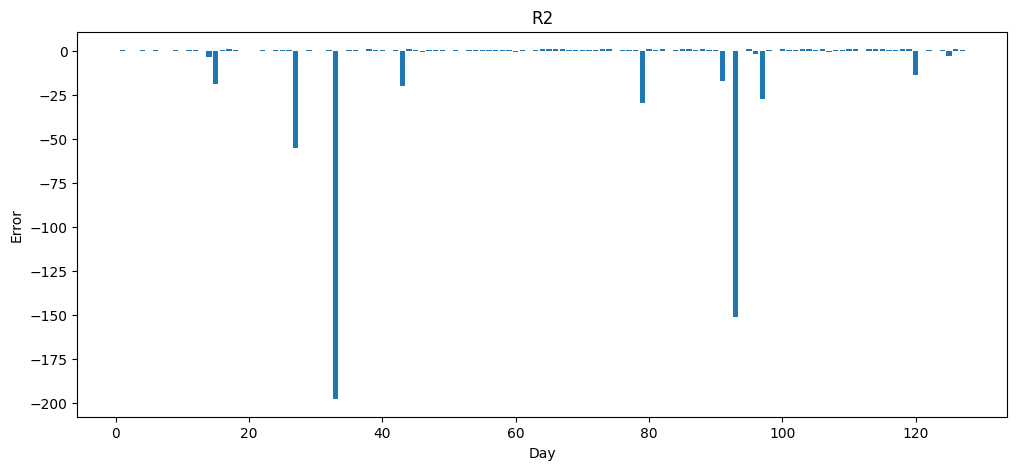

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_r2_Rear3_v2)+1), real_r2_Rear3_v2)
plt.title("R2")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

MAPE

In [ ]:
real_mape_Rear3_v2=mape_mod(yR_Rear3_test,predict_Rear3_p1_v2)
print(np.mean(real_mape_Rear3_v2))

nan


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
print(real_mape_Rear3_v2)

[np.float64(0.5592308264422116), np.float64(0.47234094929758613), np.float64(0.4423044616120578), np.float64(0.4099622970239473), np.float64(0.39895860555206764), np.float64(0.35737343909158903), np.float64(0.6941786988104317), np.float64(0.7233021188151765), np.float64(0.36360851573972314), np.float64(0.6872538732125799), np.float64(0.20550916234516678), np.float64(0.6037792502723145), np.float64(0.7589823569993531), np.float64(0.7732898230044697), np.float64(1.282849065842398), np.float64(0.8184913240382788), np.float64(0.3111763170948783), np.float64(0.35957334774688576), np.float64(0.23128183595101695), np.float64(0.6253242665991444), np.float64(0.5828762688995867), np.float64(0.2580304974973287), np.float64(0.41026606289002304), np.float64(0.5732151579082024), np.float64(0.6274915076980162), np.float64(0.505757145738839), np.float64(nan), np.float64(0.8459149981345787), np.float64(1.9823319017898036), np.float64(0.48728806783721007), np.float64(0.716935249744513), np.float64(1.312

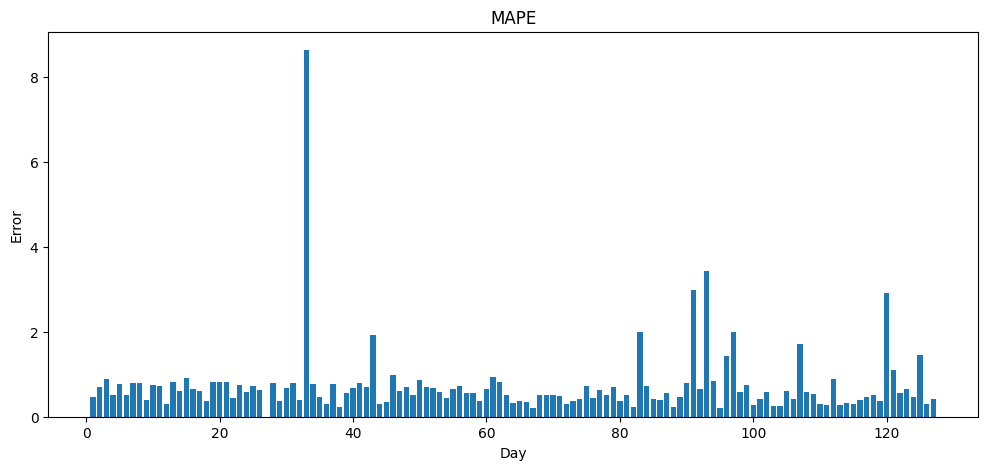

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_mape_Rear3_v2)+1), real_mape_Rear3_v2)
plt.title("MAPE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

Check the graphs to understand atypical errors

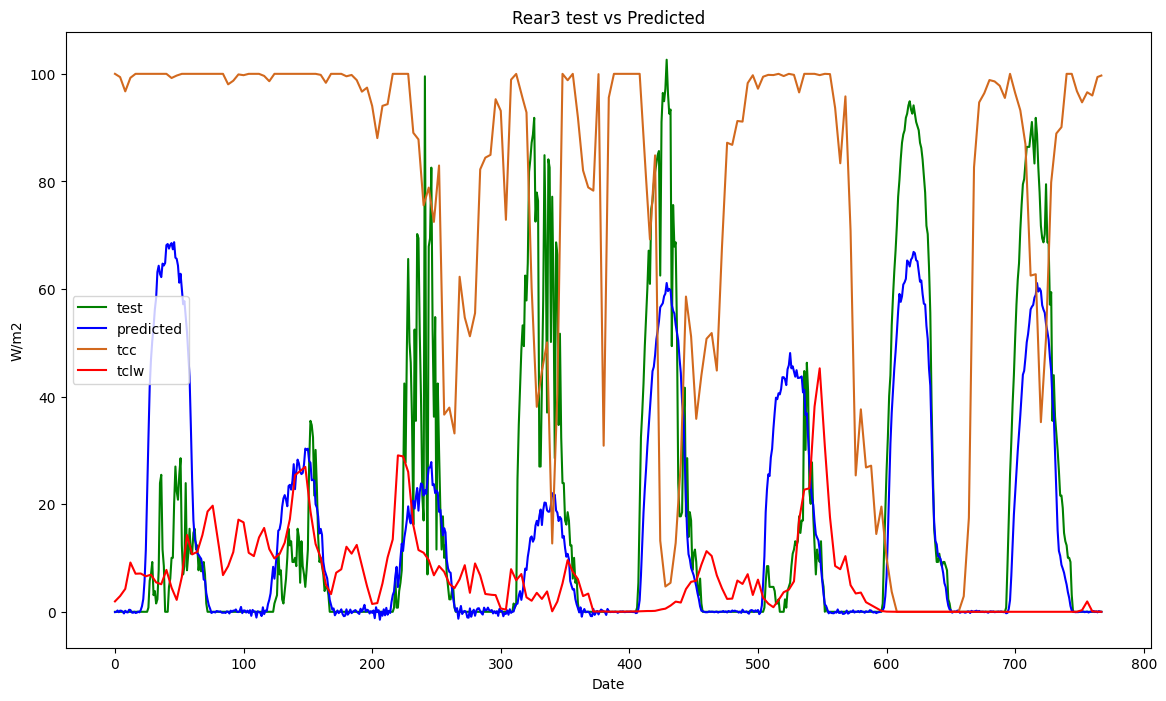

In [ ]:
plt.figure(figsize=(14,8))
st_day=120
end_day=130
dat_clouds=yR_Rear3_test.shape[0]*yR_Rear3_test.shape[1]
i_clouds=len(df3)-dat_clouds+(st_day-1)*96
f_clouds=i_clouds+(end_day-st_day)*96
plt.plot(yR_Rear3_test.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='test',color='green')
plt.plot(predict_Rear3_p1_v2.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='predicted',color='blue')
plt.plot(df3['tcc'].values[i_clouds:f_clouds],label='tcc',color='chocolate')
plt.plot(df3['tclw'].values[i_clouds:f_clouds]*50,label='tclw',color='red')
plt.title("Rear3 test vs Predicted")
plt.xlabel("Date")
plt.ylabel("W/m2")
plt.legend()
plt.show()

Model summary

In [ ]:
model1_Rear3_CNNGRU2_v2.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq-input           │ (None, 384, 14)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 384, 32)   │      1,376 │ seq-input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 384, 32)   │      3,104 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 384, 32)   │          0 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 32)        │      6,336 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ surf-input          │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      2,112 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        160 │ surf-input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 96)        │      9,312 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 96)        │      9,312 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 95,138 (371.64 KB)

 Trainable params: 31,712 (123.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 63,426 (247.76 KB)